# PCLab#5 (Hackhaton)

This notebook presents the work conducted for the Finance with Big Data hackathon, which focuses on the impact of NGO press campaigns on financial markets within the context of responsible investment. The project explores whether environmental, social, and governance (ESG)-related news—originating from NGOs, media, and other stakeholders—affects stock prices, particularly in the banking sector.

Using campaign data from Sigwatch matched with financial market data, the analysis follows an event-study approach to measure the market reaction to positive and negative ESG events. This involves computing abnormal and cumulative abnormal returns (CARs) around campaign dates, based on asset pricing models such as CAPM or Fama-French factors.

Beyond measuring market reactions, the project also investigates the role of media and social attention, sentiment, and institutional context in shaping investor responses. The ultimate goal is to assess whether NGO-driven information constitutes a relevant signal for investors and contributes to the growing field of sustainable and responsible investing.

# Imports, cleaning and first analysis

In [1]:
import pandas as pd, glob, re, os
import numpy as np
from pathlib import Path
from google.colab import drive
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import statsmodels.formula.api as smf
from wordcloud import WordCloud, STOPWORDS
import json
from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Sigwatch Data

In [ ]:
folder = Path("./data/sigwatch_data")

files = sorted([str(p) for p in folder.glob("*.dta")])
for f in files:
    print(" -", os.path.basename(f))

dfs = []
for f in files:
    m = re.search(r'(\d{4})', os.path.basename(f))
    year = int(m.group(1)) if m else None

    df = pd.read_stata(f, convert_categoricals=True)
    df["year"] = year
    dfs.append(df)


sig_data = pd.concat(dfs, ignore_index=True, sort=False)
print("Shape:", sig_data.shape)

In [ ]:
sig_data.head()

Follwing the example cleaning txt file, we firstly clean the dataset. The cleaning consistes in the following phases:
1.  We align country_corp with company_parent_country when different
2. We restrict the sample to those countries which are in Datastream database too
3. We find all actions taken by the same ngo versus the same firm in the same date and keep only the first one
4. We drop observations where the same company has opposite-sentiment events within 5 days
5. We create negative / positive /neutral dummies
6. We apply the same renaming of banks used in the txt file
7. We create a parent_company dummy

Compared to the txt file, we avoided restricting the observations to only those with negative sentiment and to those related to climate/enviroment issues.

In [ ]:
# Helper functions
def any_contains(df, cols, pattern, flags=re.I):
    pat = re.compile(pattern, flags)
    out = pd.Series(False, index=df.index)
    for c in [c for c in cols if c in df.columns]:
        s = df[c].astype(str).str.contains(pat, na=False)
        out = out | s
    return out

def first_row(group):
    """Return the first row of a group (preserves dtypes)."""
    return group.iloc[0]

def safe_cols(df, cols):
    """Keep only columns that exist in df."""
    return [c for c in cols if c in df.columns]

# date
if "date" in sig_data.columns:
    sig_data["date"] = pd.to_datetime(sig_data["date"], errors="coerce")
if "year" not in sig_data.columns and "date" in sig_data.columns:
    sig_data["year"] = sig_data["date"].dt.year



######## Actual Cleaning ########
df = sig_data.copy()


# 1) We align country_corp with company_parent_country when different
for col_needed in ["country_corp", "company_parent_country"]:
    if col_needed not in df.columns:
        df[col_needed] = np.nan
mask_diff = (df["country_corp"] != df["company_parent_country"]) & df["company_parent_country"].notna()
df.loc[mask_diff, "country_corp"] = df.loc[mask_diff, "company_parent_country"]

# 2) We restrict the sample to those countries which are in Datastream database too
keep_countries = {
    "Germany","Belgium","Cyprus","Estonia","Spain","Finland","France","Greece","Ireland","Italy",
    "Lithuania","Malta","Netherlands","Austria","Portugal","Slovenia","Slovakia","UK","US","USA",
    "Norway","Sweden","Switzerland"}

df = df[df["country_corp"].isin(keep_countries)].copy()

# 3) Collapse to first event per (company, ngo_name1, date)
# We want to find all actions taken by the same ngo versus the same firm in the same date and keep only the first one
group1_keys = ["company", "ngo_name1", "date"]
agg_prom = df.groupby(group1_keys)["prominence"].agg(prominence_mean="mean", maxprominence="max") if "prominence" in df.columns else pd.DataFrame()
agg_sent = df.groupby(group1_keys)["sentiment"].agg(sentiment_mean="mean", minsentiment="min") if "sentiment" in df.columns else pd.DataFrame()

df_sorted = df.sort_values(group1_keys)
first_snapshot = df_sorted.groupby(group1_keys, as_index=False).apply(first_row).reset_index(drop=True)

first_snapshot = first_snapshot.merge(agg_prom.reset_index(), on=group1_keys, how="left")
first_snapshot = first_snapshot.merge(agg_sent.reset_index(), on=group1_keys, how="left")

df = first_snapshot.copy()
if "year" not in df.columns and "date" in df.columns:
    df["year"] = df["date"].dt.year
df = df.sort_values(["company","date"]).reset_index(drop=True)


# 4) Drop observations where same company has opposite-sentiment events within 5 days
df = df.sort_values(["company","date"]).reset_index(drop=True)
def flag_opposite(g):
    g = g.sort_values("date")
    prev_close = (g["date"] - g["date"].shift(1)).dt.days.le(5)
    next_close = (g["date"].shift(-1) - g["date"]).dt.days.le(5)
    prev_opp = prev_close & (g["sentiment"] * g["sentiment"].shift(1) < 0)
    next_opp = next_close & (g["sentiment"] * g["sentiment"].shift(-1) < 0)
    return (prev_opp | next_opp)
opp = df.groupby("company", group_keys=False).apply(flag_opposite).reindex(df.index, fill_value=False)
df = df.loc[~opp].copy()

# 5) negative / positive /neutral dummies
df["negative"] = (df["sentiment"] < 0).astype(int)
df["positive"] = (df["sentiment"] > 0).astype(int)
df["neutral"]= (df["sentiment"] == 0).astype(int)


# 6) Rename banks to Datastream names
if "company" in df.columns:
    df["company"] = df["company"].astype(str).str.lower()

rename_map = {
    "abn amro bank n.v.": "abn amro bank",
    "bank of ireland ": "bank of ireland group",
    "barclays bank": "barclays",
    "discover card": "discover financial svs.",
    "grupo santander": "banco santander",
    "gruppo assicurazioni generali": "banca generali",
    "hsbc": "hsbc holdings",
    "ing": "ing groep",
    "kbc bank": "kbc group",
    "lloyds banking group plc": "lloyds banking group",
    "lloyd's of london": "lloyds banking group",
    "nibc": "nibc holding",
    "standard chartered bank": "standard chartered",
    "van lanschot": "van lanschot kempen",
    "wells fargo & wachovia": "wells fargo & co",
    "rbs": "royal bank of sctl.gp.",
    "royal bank of scotland (rbs)": "royal bank of sctl.gp.",
    "rbs group": "royal bank of sctl.gp.",
    "allied irish banks p.l.c. (aib)": "aib group",
    "hsbc global asset management": "hsbc holdings",
    "pnc bank": "pnc finl.svs.gp.",
    "banca monte dei paschi": "banca monte dei paschi",
    "banco sabadell": "banco de sabadell",
    "bank of america": "bank of america",
    "bank of ireland": "bank of ireland group",
    "bankinter, s.a.": "bankinter r",
    "bbva group / banco bilbao vizcaya argentaria": "bbv.argentaria",
    "bnp paribas": "bnp paribas",
    "caixabank": "caixabank",
    "citizens financial group": "citizens financial group",
    "comerica": "comerica",
    "credit agricole": "credit agricole",
    "discover financial services": "discover financial svs.",
    "erste group": "erste group bank",
    "fifth third bank": "fifth third bancorp",
    "huntington bank": "huntington bcsh.",
    "intesa sanpaolo": "intesa sanpaolo",
    "keycorp": "keycorp",
    "liberbank": "liberbank",
    "m&t bank": "m&t bank",
    "metro bank": "metro bank",
    "natixis": "natixis",
    "nordea": "nordea bank",
    "peoples united bank": "peoples united financial",
    "permanent tsb": "permanent tsb ghg.",
    "societe generale": "societe generale",
    "svb financial": "svb financial group",
    "synovus financial": "synovus financial",
    "tcf bank": "tcf financial",
    "umweltbank": "umweltbank",
    "unicaja": "unicaja banco",
    "unicredit": "unicredit",
    "us bancorp": "us bancorp",
    "virgin money": "virgin money uk",
    "zions bank": "zions bancorp.",
    "ace group": "ace cash express",
    "aegon bank": "aegon",
    "allianz se": "allianz group / allianz se",
    "bank of new york mellon / bny mellon": "bank of new york mellon",
    "berkshire hathaway": "berkshire bank",
    "dnb norway": "dnb",
    "pinnacle west capital corporation": "pinnacle financial ptns.",
    "schweizerische nationalbank (snb)": "schweizerische nat.bk.",
    "sparebank1 group": "sparebank 1 sr-bank",
    "swedbank ab": "swedbank a",
    "virgin group": "virgin money uk"}

df["company"] = df["company"].replace(rename_map)


# 7) parent_company dummy
df["parent_company"] = (df["company_type"] == "Parent").astype(int)


# Final ordering
order_cols = [c for c in ["date", "company", "ngo_name1", "prominence", "sentiment"] if c in df.columns]
df = df.sort_values(order_cols).reset_index(drop=True)

print("Final shape:", df.shape)
df.head()

/tmp/ipython-input-2982368422.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_snapshot = df_sorted.groupby(group1_keys, as_index=False).apply(first_row).reset_index(drop=True)
/tmp/ipython-input-2982368422.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  opp = df.groupby("company", group_keys=False).apply(flag_opposite).reindex(df.index, fill_value=False)


Final shape: (52763, 103)


,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,...,link5,year,prominence_mean,maxprominence,sentiment_mean,minsentiment,negative,positive,neutral,parent_company
0,30955,2010-01-04,1,monsanto,Parent,1,Monsanto,US,-1,2,...,NaN,2010,2.0,2,-1.0,-1,1,0,0,1
1,30959,2010-01-04,1412,vinci,Parent,1412,Vinci,France,-1,2,...,NaN,2010,2.0,2,-1.0,-1,1,0,0,1
2,30967,2010-01-06,7,bp,Parent,7,BP,UK,-2,2,...,NaN,2010,2.0,2,-2.0,-2,1,0,0,1
3,36247,2010-01-06,4,pfizer,Parent,4,Pfizer,US,-1,2,...,NaN,2010,2.0,2,-1.0,-1,1,0,0,1
4,30962,2010-01-06,1136,syngenta,Parent,1136,Syngenta,Switzerland,-2,2,...,NaN,2010,2.0,2,-2.0,-2,1,0,0,1


In [ ]:
sig_cleaned = df.copy()
sig_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52763 entries, 0 to 52762
Columns: 103 entries, uid_archive to parent_company
dtypes: datetime64[ns](1), float32(5), float64(31), int16(8), int32(1), int64(5), int8(5), object(47)
memory usage: 36.1+ MB


## Bank Data

In [ ]:
banks_info = pd.read_excel("./data/banks_data/banks_info.xlsx", sheet_name=None)

# we exlcude the first sheet
sheet_names = list(banks_info.keys())
banks_info_no_first = {k: banks_info[k] for k in sheet_names[1:]}

# we identify the banks names
banks_df= pd.concat(banks_info_no_first.values(), ignore_index=True)

In [ ]:
banks_df.head()

,NaN,NAME,MNEMONIC,GEOGRAPHIC DESCR.,TRBC ECON SEC NAME,ISIN CODE,ISIN NUMBER,ISIN ISSUER CTRY
0,S43302,GERMANY-DS Banks,BANKSBD,GERMANY,NaN,NaN,NaN,NaN
1,S52002,BELGIUM-DS Banks,BANKSBG,BELGIUM,NaN,NaN,NaN,NaN
2,L12502,CYPRUS-DS Banks,BANKSCP,CYPRUS,NaN,NaN,NaN,NaN
3,L18502,ESTONIA-DS Banks,BANKSEO,ESTONIA,NaN,NaN,NaN,NaN
4,S50902,SPAIN-DS Banks,BANKSES,SPAIN,NaN,NaN,NaN,NaN


In [ ]:
# we want to find all the unique values of GEOGRAPHIC DESCR.

banks_df["GEOGRAPHIC DESCR."].unique()

array(['GERMANY', 'BELGIUM', 'CYPRUS', 'ESTONIA', 'SPAIN', 'FINLAND',
       'FRANCE', 'GREECE', 'IRELAND', 'ITALY', 'LITHUANIA', 'MALTA',
       'NETHERLANDS', 'AUSTRIA', 'PORTUGAL', 'SLOVENIA', 'SLOVAKIA', nan],
      dtype=object)

In [ ]:
# or equivalently to issuer ctry
banks_df["ISIN ISSUER CTRY"].unique()

array([nan, 'DE', 'BE', 'IE', 'CY', 'EE', 'ES', 'FI', 'FR', 'MC', 'GR',
       'IT', 'LT', 'MT', 'NL', 'AT', 'PT', 'SI', 'SK', 'US', 'BM', 'PR',
       'GB'], dtype=object)

This confirms that all the banks we have are already either US/EU

In [ ]:
# we identify the names of all the banks listed in banks_info
banks_names = banks_df['NAME'].str.lower().unique()
banks_names

array(['germany-ds banks', 'belgium-ds banks', 'cyprus-ds banks',
       'estonia-ds banks', 'spain-ds banks', 'finland-ds banks',
       'france-ds banks', 'greece-ds banks', 'ireland-ds banks',
       'italy-ds banks', 'lithuania-ds banks', 'malta-ds banks',
       'netherland-ds banks', 'austria-ds banks', 'portugal-ds banks',
       'slovenia-ds banks', 'slovakia-ds banks', 'aareal bank',
       'comdirect bank', 'commerzbank', 'dt.pfandbriefbank',
       'procredit holding', 'umweltbank', 'allianz group / allianz se',
       'deutsche bank', 'banque nationale de belgique', 'kbc ancora',
       'kbc group', 'bank of cyprus holding', 'hellenic bank',
       'lhv group', 'bbv.argentaria', 'banco de sabadell',
       'banco santander', 'bankia', "bankinter 'r'", 'caixabank',
       'liberbank', 'unicaja banco', 'aktia bank a', 'nordea bank',
       'bnp paribas', 'crcam ille-vil.cci', 'crcam nord cci',
       'credit agricole', 'credit agricole brie picardie',
       'credit agr.ile d

## Selecting only banks data

In [ ]:
banks_ngo = sig_cleaned[sig_cleaned['company'].str.lower().isin(banks_names)].reset_index(drop=True)
banks_ngo['company'] = banks_ngo['company'].str.lower()
banks_ngo.head()

,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,...,link5,year,prominence_mean,maxprominence,sentiment_mean,minsentiment,negative,positive,neutral,parent_company
0,31400,2010-02-12,1254,pinnacle financial ptns.,Parent,1254,Pinnacle West Capital Corporation,US,1,2,...,NaN,2010,2.0,2,1.0,1,0,1,0,1
1,31562,2010-02-26,170,bnp paribas,Parent,170,BNP Paribas,France,-1,2,...,NaN,2010,2.0,2,-1.0,-1,1,0,0,1
2,32011,2010-04-05,170,bnp paribas,Parent,170,BNP Paribas,France,-2,2,...,NaN,2010,2.0,2,-2.0,-2,1,0,0,1
3,32011,2010-04-05,372,citigroup,Parent,372,Citigroup,US,-2,2,...,NaN,2010,2.0,2,-2.0,-2,1,0,0,1
4,32011,2010-04-05,171,deutsche bank,Parent,171,Deutsche Bank,Germany,-2,2,...,NaN,2010,2.0,2,-2.0,-2,1,0,0,1


## Describing the data

In [ ]:
print(f"The total number of campaigns is: {banks_ngo['uid_archive'].nunique()}")
print(f"The total number of banks is: {len(banks_ngo.groupby('company').size())}")
print(f"The total number of NGOs is: {banks_ngo['ngo_name1'].nunique()}")

The total number of campaigns is: 1260
The total number of banks is: 83
The total number of NGOs is: 369


As described in the Note_Sigwatch_Data.pdf:

**sentiment**: tone of mention of corporate in activist communication, coded by Sigwatch into one of the following: -2 (very negative), -1 (negative), 0 (neutral), +1 (positive), +2 (very positive). Positive numbers indicate that NGOs praised the firm, and negative numbers designate criticism towards the firm’s action.

**prominence**: prominence of mention of corporate in the activist communication, coded by Sigwatch into one of the following : +4 (mentioned in headline), +3 (mentioned in first paragraph or opening text), +2 (mentioned elsewhere in communication, +1 (mentioned only in accompanying report or document, if there is one)

**ngo power**: Value reflecting geographical reach of activist group, on a scale running from local (lowest value) to global (highest value)

---

Looking more in depth in the above described variables, sentiment is the most surprising one: **negative sentiments** are much more frequent compared to positive or neutral ones, with the latters corresponding only to 12.3% of the total evenets. This implies that **NGOs often criticise firm's actions**.

In [ ]:
banks_ngo.loc[:, ['prominence', 'ngo_power1', 'sentiment']].describe()

,prominence,ngo_power1,sentiment
count,2823.000000,2823.000000,2823.000000
mean,2.475735,1.590241,-1.161530
std,0.974168,0.642018,1.059924
min,1.000000,0.500000,-2.000000
25%,2.000000,1.000000,-2.000000
50%,2.000000,1.500000,-1.000000
75%,3.000000,2.500000,-1.000000
max,4.000000,2.750000,2.000000


<Axes: title={'center': 'Sentiment Percentage'}, ylabel='n'>

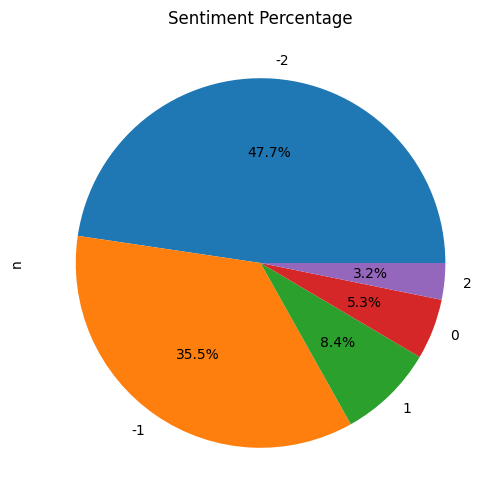

In [ ]:
sentiment = banks_ngo['sentiment'].value_counts(dropna=False).rename_axis('sentiment').to_frame('n')
sentiment_pct = (sentiment['n'] / sentiment['n'].sum()).round(3)
sentiment_pct.plot(kind='pie', title='Sentiment Percentage', autopct='%1.1f%%', figsize=(6, 6))

# **Task 2**: Social media coverage of press campaigns

This section connects to the **Reddit API** using the praw library to collect public posts that mention both companies and NGOs from our dataset. By searching across several major subreddits such as worldnews, news, finance, and environment, the script identifies online discussions related to corporate–NGO interactions around key event dates. Each query combines company and NGO names—for example, "Shell" ("Greenpeace" OR "WWF")—and retrieves posts within a ±7-day window of the event. The results, including post titles, subreddits, scores, and permalinks, are stored in the dataset.

We commented the below code which we used to call the API and directly upload the dataset with the results for summaries and plots.

In [ ]:
#os.environ["REDDIT_CLIENT_ID"] = getpass("REDDIT_CLIENT_ID: ")
#os.environ["REDDIT_CLIENT_SECRET"] = getpass("REDDIT_CLIENT_SECRET: ")
#os.environ["REDDIT_USER_AGENT"] = "script:ngo_reddit_api:0.1 (by /u/QuestionShot6943)"

In [ ]:
#reddit = praw.Reddit(
#    client_id=os.environ["REDDIT_CLIENT_ID"],
#    client_secret=os.environ["REDDIT_CLIENT_SECRET"],
#    user_agent=os.environ["REDDIT_USER_AGENT"]
#)

#print(reddit.read_only)  # should print: True
#print(reddit.user.me())  # should print: None (you’re in read-only mode)

In [ ]:
#reddit = praw.Reddit(
#    client_id=os.environ["REDDIT_CLIENT_ID"],
#    client_secret=os.environ["REDDIT_CLIENT_SECRET"],
#    user_agent=os.environ["REDDIT_USER_AGENT"]
#)

# Quick sanity checks
#print("Read-only mode:", reddit.read_only)
#print("Authenticated user:", reddit.user.me())

In [ ]:
#CHECKPOINT_PATH = "reddit_scrape_checkpoint.csv"
#OUTPUT_PATH = "banks_ngo_with_reddit.csv"

#WINDOW_DAYS = 7                # ± days around each row's `date`
#LIMIT_PER_QUERY = 1000
#SLEEP_BETWEEN_ROWS = (0.5, 1.5)  # polite jitter between rows (seconds)
#SAVE_EVERY_N_ROWS = 25         # checkpoint cadence
#TIME_FILTER = "all"           # 'day'|'week'|'month'|'year'|'all' — broad pull before local filter

In [ ]:
# Quiet noisy logs
#import logging
#logging.getLogger("praw").setLevel(logging.ERROR)
#logging.getLogger("prawcore").setLevel(logging.ERROR)

# Subreddits to try before r/all
#SUBREDDITS = ["worldnews", "environment", "sustainability", "news", "economics", "finance", "all"]

#def normalize_name(s: str) -> str:
 #   if not s:
  #      return ""
   # s = str(s).strip()
   # s = s.replace("&", "and")
   # return " ".join(s.split())

#def build_query(company, ngos):
 #   """
 #   Builds a boolean query like: "Shell" ("Greenpeace" OR "WWF")
 #   """
 #   company = normalize_name(company)
 #   ngos = [normalize_name(n) for n in ngos if pd.notna(n) and str(n).strip()]
 #   if ngos:
 #       or_block = " OR ".join([f'"{n}"' for n in ngos])
 #       return f'"{company}" ({or_block})'
 #   return f'"{company}"'

#from datetime import timezone

#def get_window(date_value, window_days=7):
#    """
#    Returns (start_dt, end_dt) as tz-aware UTC datetimes, or (None, None) if invalid.
#    """
#    if pd.isna(date_value):
#        return None, None
#    try:
#        center = pd.to_datetime(date_value, utc=True)
#    except Exception:
#        return None, None
#    start = center - pd.Timedelta(days=window_days)
#    end   = center + pd.Timedelta(days=window_days)
#    return start.to_pydatetime(), end.to_pydatetime()

#def contains_any(text, names):
#    t = (text or "").lower()
#    return any(n and n.lower() in t for n in names if n)

#def _praw_search_iter(reddit, subreddit_name, query, time_filter, limit):
#    return reddit.subreddit(subreddit_name).search(
#        query,
#        sort="new",
#        time_filter=time_filter,
#        limit=limit
#    )

#def fetch_reddit_posts_multi_subs(reddit, query, start_dt, end_dt, limit=1000, time_filter="all", subreddits=SUBREDDITS):
#    """
#    Searches each subreddit in `subreddits` (in order), then r/all.
#    Locally filters by [start_dt, end_dt] and de-duplicates by id.
#    """
#    posts = []
#    seen = set()

#    for sub in subreddits:
#        try:
#            for s in _praw_search_iter(reddit, sub, query, time_filter, limit):
#                created = datetime.fromtimestamp(s.created_utc, tz=timezone.utc)
#                if start_dt <= created <= end_dt:
#                    tid = s.id
#                    if tid not in seen:
#                        seen.add(tid)
#                        posts.append({
#                            "id": tid,
#                            "created_utc": created.isoformat(),
#                            "title": s.title,
#                            "selftext": s.selftext,
#                            "subreddit": str(s.subreddit),
#                            "url": s.url,
#                            "score": int(getattr(s, "score", 0) or 0),
#                            "num_comments": int(getattr(s, "num_comments", 0) or 0),
#                            "author": str(getattr(s, "author", "")),
#                            "permalink": f"https://www.reddit.com{s.permalink}",
#                            "over_18": bool(getattr(s, "over_18", False)),
#                        })
#        except (RequestException, ResponseException, ServerError, Forbidden) as e:            pass

#    return posts

In [ ]:
## banks_ngo = pd.read_csv("banks_ngo.csv")

#required_cols = {"company", "date", "ngo_name1", "ngo_name2", "ngo_name3"}
#missing = required_cols - set(banks_ngo.columns)
#if missing:
#    raise ValueError(f"banks_ngo is missing required columns: {missing}")

#for col in ["company", "ngo_name1", "ngo_name2", "ngo_name3"]:
#    banks_ngo[col] = banks_ngo[col].fillna("").astype(str).str.strip()

#for col in ["reddit_results", "reddit_count", "reddit_query"]:
#    if col not in banks_ngo.columns:
#        banks_ngo[col] = np.nan

#banks_ngo.head(3)

In [ ]:
# for col in ["reddit_results", "reddit_count", "reddit_query", "reddit_strategy", "reddit_error"]:
#     if col not in banks_ngo.columns:
#         banks_ngo[col] = np.nan
#
# print(f"Starting Reddit scraping for {len(banks_ngo)} rows...\n")
#
# rows_processed = 0
# pbar = tqdm(total=len(banks_ngo), desc="Reddit scraping", dynamic_ncols=True, leave=False)
#
# for i, row in banks_ngo.iterrows():
#     company = row["company"]
#     ngos = [row.get("ngo_name1",""), row.get("ngo_name2",""), row.get("ngo_name3","")]
#     query_full = build_query(company, ngos)
#
#     start_dt, end_dt = get_window(row["date"], WINDOW_DAYS)
#     if start_dt is None:
#         banks_ngo.loc[i, ["reddit_results", "reddit_count", "reddit_query",
#                           "reddit_strategy", "reddit_error"]] = (
#             json.dumps([]), 0, query_full, "skipped_invalid_date", None
#         )
#         pbar.update(1)
#         continue
#
#     strategy_used = None
#     error_msg = None
#     posts = []
#
#     try:
#         posts = fetch_reddit_posts_multi_subs(
#             reddit, query_full, start_dt, end_dt,
#             limit=LIMIT_PER_QUERY, time_filter=TIME_FILTER, subreddits=SUBREDDITS
#         )
#         if posts:
#             strategy_used = "A_full_boolean"
#         else:
#             # fallback strategy: company-only → local NGO filter ---
#             comp_q = f'"{normalize_name(company)}"' if company else ""
#             raw = fetch_reddit_posts_multi_subs(
#                 reddit, comp_q, start_dt, end_dt,
#                 limit=LIMIT_PER_QUERY, time_filter=TIME_FILTER, subreddits=SUBREDDITS
#             )
#             posts = [r for r in raw if contains_any((r.get("title","") + " " + r.get("selftext","")), ngos)]
#             strategy_used = "B_company_then_ngofilter"
#     except Exception as e:
#         posts = [{"error": True, "message": str(e), "query": query_full}]
#         strategy_used = "error"
#         error_msg = str(e)
#
#     count = 0 if (len(posts) == 1 and isinstance(posts[0], dict) and posts[0].get("error")) else len(posts)
#
#     # Save results
#     banks_ngo.loc[i, "reddit_results"] = json.dumps(posts, ensure_ascii=False)
#     banks_ngo.loc[i, "reddit_count"] = count
#     banks_ngo.loc[i, "reddit_query"] = query_full
#     banks_ngo.loc[i, "reddit_strategy"] = strategy_used
#     banks_ngo.loc[i, "reddit_error"] = error_msg
#
#     rows_processed += 1
#     pbar.set_postfix({"this_query_posts": count, "strategy": strategy_used})
#     pbar.update(1)
#
#     # print summary for row
#     print(f"Row {i} | {query_full} | Posts: {count} | Strategy: {strategy_used}")
#
#     # checkpoint save
#     if rows_processed % SAVE_EVERY_N_ROWS == 0:
#         banks_ngo.to_csv(CHECKPOINT_PATH, index=False)
#         pbar.write(f"Saved checkpoint after {rows_processed} rows")
#
#     time.sleep(random.uniform(*SLEEP_BETWEEN_ROWS))
#
# pbar.close()
# print("Loop complete.")


In [ ]:
df_reddit = pd.read_csv('./data/banks_ngo_with_reddit.csv')
df_reddit

,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,...,minsentiment,negative,positive,neutral,parent_company,reddit_results,reddit_count,reddit_query,reddit_strategy,reddit_error
0,31400,2010-02-12,1254,pinnacle financial ptns.,Parent,1254,Pinnacle West Capital Corporation,US,1,2,...,1,0,1,0,1,[],0.0,"""pinnacle financial ptns."" (""Ceres/INCR"")",A_full_boolean,NaN
1,31562,2010-02-26,170,bnp paribas,Parent,170,BNP Paribas,France,-1,2,...,-1,1,0,0,1,[],0.0,"""bnp paribas"" (""Amis de la Terre France / FoE ...",A_full_boolean,NaN
2,32011,2010-04-05,170,bnp paribas,Parent,170,BNP Paribas,France,-2,2,...,-2,1,0,0,1,[],0.0,"""bnp paribas"" (""FairFin (previously Netwerk Vl...",A_full_boolean,NaN
3,32011,2010-04-05,372,citigroup,Parent,372,Citigroup,US,-2,2,...,-2,1,0,0,1,[],0.0,"""citigroup"" (""FairFin (previously Netwerk Vlaa...",A_full_boolean,NaN
4,32011,2010-04-05,171,deutsche bank,Parent,171,Deutsche Bank,Germany,-2,2,...,-2,1,0,0,1,[],0.0,"""deutsche bank"" (""FairFin (previously Netwerk ...",A_full_boolean,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,87496,2018-12-18,171,deutsche bank,Parent,171,Deutsche Bank,Germany,1,2,...,1,0,1,0,1,[],0.0,"""deutsche bank"" (""Test Achats / Test Aankoop"")",A_full_boolean,NaN
2819,87514,2018-12-18,222,hsbc holdings,Parent,222,HSBC,UK,-2,2,...,-2,1,0,0,1,[],0.0,"""hsbc holdings"" (""Kiko Network"")",A_full_boolean,NaN
2820,87496,2018-12-18,379,ing groep,Parent,379,ING,Netherlands,-1,2,...,-1,1,0,0,1,[],0.0,"""ing groep"" (""Test Achats / Test Aankoop"")",A_full_boolean,NaN
2821,87514,2018-12-18,1065,standard chartered,Parent,1065,Standard Chartered Bank,UK,-2,2,...,-2,1,0,0,1,[],0.0,"""standard chartered"" (""Kiko Network"")",A_full_boolean,NaN


In [ ]:
df_reddit.columns = df_reddit.columns.str.replace(r"\s+", " ", regex=True).str.strip()

# 1) Costruisci/forza _reddit_count
if "reddit_count" in df_reddit.columns:
    df_reddit["_reddit_count"] = pd.to_numeric(
        df_reddit["reddit_count"], errors="coerce"
    ).fillna(0).astype(np.int64)
else:
    def _safe_len(x):
        if pd.isna(x) or (isinstance(x, str) and x.strip() == ""):
            return 0
        try:
            obj = json.loads(x)
            return len(obj) if isinstance(obj, list) else 0
        except Exception:
            return 0
    df_reddit["_reddit_count"] = (
        df_reddit.get("reddit_results", pd.Series([np.nan]*len(df_reddit)))
        .apply(_safe_len)
        .fillna(0)
        .astype(np.int64)
    )

# 2) Calcola la maschera FRESCA (subito prima di usarla)
has_posts_mask = df_reddit["_reddit_count"].gt(0)

# 3) Diagnostica utile
print("Colonne:", df_reddit.columns.tolist())
print("_reddit_count dtype:", df_reddit["_reddit_count"].dtype)
print("Righe con _reddit_count > 0:", int(has_posts_mask.sum()))
print("Esempi _reddit_count:", df_reddit["_reddit_count"].value_counts().head(10).to_dict())

# 4) Subset sicuro + costruzione posts_df
subset = df_reddit.loc[has_posts_mask].copy()

def row_to_posts(row):
    raw = row.get("reddit_results", np.nan)
    posts = []
    parsed = None
    if isinstance(raw, str) and raw.strip():
        try:
            parsed = json.loads(raw)
        except Exception:
            parsed = None
    source_posts = parsed if isinstance(parsed, list) and parsed else [{} for _ in range(int(row["_reddit_count"]))]
    for p in source_posts:
        posts.append({
            "title": (p.get("title") if isinstance(p, dict) else None),
            "selftext": (p.get("selftext") if isinstance(p, dict) else None),
            "sentiment": row.get("sentiment", np.nan),
            "prominence": row.get("prominence", np.nan),
        })
    return posts

post_records = []
for _, r in subset.iterrows():
    post_records.extend(row_to_posts(r))

posts_df = pd.DataFrame(post_records)
print("Total rows with ≥1 post:", len(subset))
print("Total Reddit posts identified:", len(posts_df))

Colonne: ['uid_archive', 'date', 'company_code', 'company', 'company_type', 'company_parent_code', 'company_parent', 'company_parent_country', 'sentiment', 'prominence', 'partnership', 'issue_code1', 'issue_name1', 'issue_code2', 'issue_name2', 'issue_code3', 'issue_name3', 'active_country_code1', 'active_country1', 'active_country_code2', 'active_country2', 'active_country_code3', 'active_country3', 'active_country_code4', 'active_country4', 'active_country_code5', 'active_country5', 'active_country_code6', 'active_country6', 'target_country_code1', 'target_country1', 'target_country_code2', 'target_country2', 'target_country_code3', 'target_country3', 'target_country_code4', 'target_country4', 'target_country_code5', 'target_country5', 'target_country_code6', 'target_country6', 'ngo_code1', 'ngo_name1', 'ngo_power1', 'ngo_country_code1', 'ngo_country1', 'ngo_code2', 'ngo_name2', 'ngo_power2', 'ngo_country_code2', 'ngo_country2', 'ngo_code3', 'ngo_name3', 'ngo_power3', 'ngo_country_co

In [ ]:
# print totals
total_rows_with_posts = int(has_posts_mask.sum())
total_posts = int(len(posts_df))

print(f"Total rows with ≥ 1 Reddit post: {total_rows_with_posts:,}")
print(f"Total Reddit posts identified: {total_posts:,}")

Total rows with ≥ 1 Reddit post: 7
Total Reddit posts identified: 26


While there are clear limitations in our Reddit search, such as restricted subreddit coverage, query wording, and the ±7-day time window, the results still show that discussions around these company-NGO events are **very scarce**. Even with these constraints, it’s evident that Reddit does not host much public conversation on these issues, suggesting that such topics attract limited engagement on the platform.

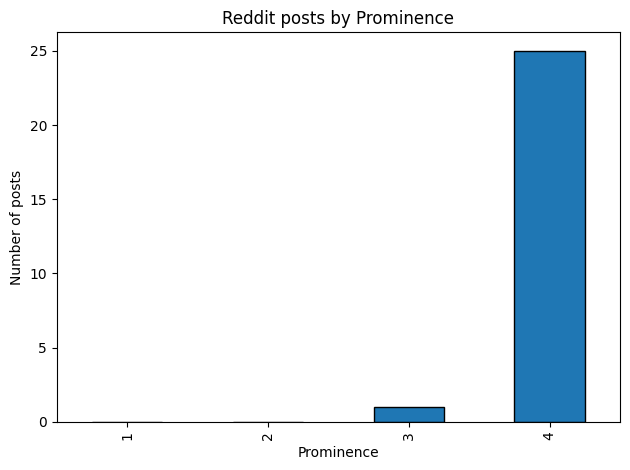

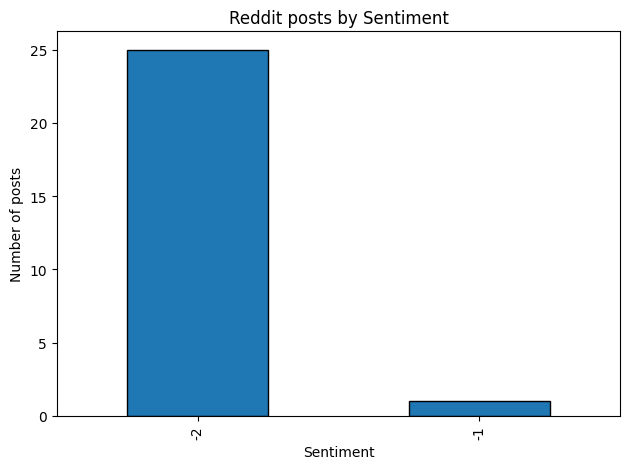

In [ ]:
# Plots
prom_counts = (
    pd.to_numeric(posts_df["prominence"], errors="coerce")
      .astype("Int64")
      .value_counts()
      .sort_index()
    )
prom_index = pd.Index([1,2,3,4], dtype="Int64")
prom_counts = prom_counts.reindex(prom_index, fill_value=0)

plt.figure()
prom_counts.plot(kind="bar", edgecolor="black")
plt.title("Reddit posts by Prominence")
plt.xlabel("Prominence")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

sent_series = posts_df["sentiment"].dropna()

if pd.api.types.is_numeric_dtype(sent_series):
    sent_series = pd.to_numeric(sent_series, errors="coerce").dropna()
    order = sorted(sent_series.unique())
    sent_counts = sent_series.value_counts().reindex(order, fill_value=0)
else:
    sent_str = sent_series.astype(str).str.strip().str.lower()
    unique_vals = list(sorted(sent_str.unique()))
    preferred = ["negative", "neutral", "positive"]
    if set(preferred).issubset(set(unique_vals)):
        order = preferred
    else:
        order = unique_vals
    sent_counts = sent_str.value_counts().reindex(order, fill_value=0)

plt.figure()
sent_counts.plot(kind="bar", edgecolor="black")
plt.title("Reddit posts by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

The majority of Reddit posts are associated with events of high prominence and lower sentiment, which aligns with expectations since highly visible events often attract more critical or negative attention.

# **Task 4**: Estimate parameters of the CAPM

## Importing additional data (banks_ri, banks_pi, ff)

### Banks_ri and Banks_pi

Here we import price and return indices of banks. We **divide the data** in two, separating European and American banks. This is due to the fact that for our further analysis we will use risk free rates that are specific for each market. Additionally, we include UK in european countries, accounting for the fact that our dataset spans the period between 2008 and 2020, while Brexit took place on 31 Jan 2020.

In [ ]:
eu_countries = ["BD","BG", "CP","EO","ES", "FN","FR","GR", "IR","IT","LN","MA", "NL","OE","PT", "SJ","SX", "UK", "SW", "NW", "SD"]

us_countries = ["US"]

In [ ]:
def loading_df(file_path, countries):
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    df_country = []
    for sheet_name, df in all_sheets.items():
        if sheet_name in countries:
            df.set_index(df.columns[0], inplace=True)
            df.index = pd.to_datetime(df.index, dayfirst=True) #index date
            df_country.append(df)
    all = pd.concat(df_country, axis=1)
    return all

In [ ]:
pi_eu_no_scan= loading_df("./data/banks_data/banks_pi.xlsm", eu_countries)
ri_eu_no_scan= loading_df("./data/banks_data/banks_ri.xlsm", eu_countries)
pi_eu_scan= loading_df("./data/banks_data/scandinavian_banks_pi.xlsm", eu_countries)
ri_eu_scan= loading_df("./data/banks_data/scandinavian_banks_ri.xlsm", eu_countries)
pi_us= loading_df("./data/banks_data/banks_pi.xlsm", us_countries)
ri_us= loading_df("./data/banks_data/banks_ri.xlsm", us_countries)

We drop the last rows of scandinavian banks dataset to match the date range of the european and american datasets.

In [ ]:
pi_eu_scan=pi_eu_scan[:"2020-04-28"]
ri_eu_scan=ri_eu_scan[:"2020-04-28"]

pi_eu = pd.concat([pi_eu_no_scan, pi_eu_scan], axis=1)
ri_eu = pd.concat([ri_eu_no_scan, ri_eu_scan], axis=1)

To avoid problems and data imbalances with our following calculations and predictions, we decided to drop the banks with missing data in their returns.

In [ ]:
print(f"We have {len(ri_eu.columns)} EU banks")
print(f"We have: {len(ri_us.columns)} US banks")

We have 126 EU banks
We have: 59 US banks


In [ ]:
ri_eu= ri_eu.dropna(axis= 1)
ri_us=ri_us.dropna(axis=1)

In [ ]:
print(f"Now we have: {len(ri_eu.columns)} EU banks")
print(f"Now we have: {len(ri_us.columns)} US banks")

Now we have: 99 EU banks
Now we have: 53 US banks


In Datastream naming,
- PI = Price Index and
- RI = Total Return Index (price + dividends).

We compute daily returns from RI, which is usually the preferred one for asset-pricing.

In [ ]:
return_eu = ri_eu.sort_index().pct_change().ffill()
return_us = ri_us.sort_index().pct_change().ffill()

In [ ]:
return_eu.head()

,AAREAL BANK - TOT RETURN IND,COMDIRECT BANK - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,UMWELTBANK - TOT RETURN IND,ALLIANZ - TOT RETURN IND,DEUTSCHE BANK - TOT RETURN IND,BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND,KBC ANCORA - TOT RETURN IND,KBC GROUP - TOT RETURN IND,HELLENIC BANK - TOT RETURN IND,...,VP BANK - TOT RETURN IND,WALLISER KANTONALBANK - TOT RETURN IND,ZUGER KANTONALBANK - TOT RETURN IND,DNB - TOT RETURN IND,SPAREBANK 1 SMN ORDS - TOT RETURN IND,SPAREBANK 1 SR-BANK - TOT RETURN IND,AVANZA BANK HOLDING - TOT RETURN IND,SKANDINAVISKA ENSKILDA BANKEN A - TOT RETURN IND,SVENSKA HANDELSBANKEN A - TOT RETURN IND,SWEDBANK A - TOT RETURN IND
Name,,,,,,,,,,,,,,,,,,,,,
2008-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-02,0.008449,-0.001209,-0.018633,-0.003575,-0.017896,-0.018886,0.009928,-0.017681,-0.012786,0.036283,...,0.000133,0.000000,0.000000,0.012045,0.003458,-0.003777,0.009227,-0.009064,-0.009661,-0.005470
2008-01-03,-0.011316,0.000000,-0.012013,0.009529,-0.005638,-0.000458,-0.000626,-0.019827,-0.012109,-0.031945,...,-0.032869,0.000000,-0.008943,-0.021427,0.006893,-0.007575,-0.005486,0.009147,-0.009757,0.002757
2008-01-04,-0.046332,0.001210,-0.005492,0.005923,-0.019777,-0.009684,-0.015249,-0.006701,-0.011405,0.009813,...,-0.031224,-0.006156,0.003000,-0.009729,0.003432,0.007632,-0.045956,-0.024168,-0.017243,-0.027396
2008-01-07,-0.031158,0.003324,0.003543,-0.014701,-0.012628,-0.000574,-0.003547,0.016053,0.013586,-0.016705,...,0.001102,0.007226,0.009021,0.000000,-0.010243,-0.018940,-0.038534,-0.006192,0.007520,-0.005639


In [ ]:
return_us.head()

,BANK OF AMERICA - TOT RETURN IND,TRUIST FINANCIAL - TOT RETURN IND,BOK FINL. - TOT RETURN IND,COMERICA - TOT RETURN IND,COMMERCE BCSH. - TOT RETURN IND,CREDICORP - TOT RETURN IND,CULLEN FO.BANKERS - TOT RETURN IND,DISCOVER FINANCIAL SVS. - TOT RETURN IND,EAST WEST BANCORP - TOT RETURN IND,FIFTH THIRD BANCORP - TOT RETURN IND,...,AMERICAN EXPRESS - TOT RETURN IND,AMERICAN INTL.GP. - TOT RETURN IND,AXIS CAPITAL HDG. - TOT RETURN IND,BANK OF NEW YORK MELLON - TOT RETURN IND,BERKSHIRE HILLS BANCORP - TOT RETURN IND,CITIGROUP - TOT RETURN IND,GOLDMAN SACHS GP. - TOT RETURN IND,JP MORGAN CHASE & CO. - TOT RETURN IND,LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - TOT RETURN IND,MASTERCARD - TOT RETURN IND
Name,,,,,,,,,,,,,,,,,,,,,
2008-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-02,-0.016966,-0.036519,-0.017600,-0.017920,-0.017164,-0.014812,-0.030597,-0.011930,-0.035494,-0.028651,...,-0.015377,-0.034306,-0.001268,-0.033429,-0.005765,-0.017661,-0.034643,-0.025203,0.043222,-0.002403
2008-01-03,-0.006409,-0.014551,-0.021070,-0.031579,-0.021318,0.008646,-0.013032,-0.004791,-0.015409,0.006555,...,-0.012344,0.002665,-0.012096,0.043285,-0.010054,0.000345,-0.013286,-0.006875,0.044781,-0.011935
2008-01-04,-0.011168,-0.060440,-0.009853,-0.035748,-0.021318,-0.016880,-0.030534,-0.059888,-0.021726,-0.032152,...,-0.025192,-0.020372,0.014326,-0.020745,-0.040668,-0.023849,-0.023967,-0.022683,-0.000422,-0.051530
2008-01-07,0.001256,0.014987,0.019090,0.015781,0.014441,0.008988,0.026600,0.031544,-0.032873,-0.023129,...,0.004476,0.018082,0.001509,0.013707,0.005315,0.000707,-0.026007,0.010015,0.008272,-0.003366


### Fama French Factors and RF

Here we import the fama french data. We divide the rates by 100 because they were displayed as percentages. For the risk free rate, we transfrom it into daily risk rate, under the convention of discrete daily compounding.

$$(1+rf)^{1/252} -1$$

In [ ]:
# EU
ff_eu = pd.read_excel("./data/banks_data/Europe_3_Factors_Daily.xlsx")
ff_eu["date"] = pd.to_datetime(ff_eu['date'], format='%m/%d/%Y')
ff_eu = ff_eu.sort_values("date").set_index("date")

ff_eu[["Mkt-RF", "SMB", "HML"]] = ff_eu[["Mkt-RF", "SMB", "HML"]].astype(float) / 100.0

ff_eu = ff_eu.loc[return_eu.index.min():return_eu.index.max()]

# US
ff_us = pd.read_excel("./data/banks_data/North_America_3_Factors_Daily.xlsx")
ff_us["date"] = pd.to_datetime(ff_us["date"], dayfirst=False, errors="coerce")
ff_us = ff_us.sort_values("date").set_index("date")

ff_us[["Mkt-RF", "SMB", "HML"]] = ff_us[["Mkt-RF", "SMB", "HML"]].astype(float) / 100.0

ff_us = ff_us.loc[return_us.index.min():return_us.index.max()]

print(ff_eu.head())
print(ff_us.head())

            Mkt-RF     SMB     HML    RF
date                                    
2008-01-01  0.0002  0.0000  0.0000  0.01
2008-01-02 -0.0011  0.0094  0.0023  0.01
2008-01-03 -0.0013 -0.0022  0.0011  0.01
2008-01-04 -0.0174  0.0039  0.0030  0.01
2008-01-07 -0.0079 -0.0103  0.0016  0.01
            Mkt-RF     SMB     HML    RF
date                                    
2008-01-01  0.0004  0.0005  0.0001  0.01
2008-01-02 -0.0125  0.0009 -0.0022  0.01
2008-01-03 -0.0003 -0.0066 -0.0042  0.01
2008-01-04 -0.0259 -0.0045  0.0029  0.01
2008-01-07  0.0002 -0.0022  0.0024  0.01


In [ ]:
ff_eu['RF'] = (1 + ff_eu['RF']) ** (1/252) - 1
ff_us['RF'] = (1 + ff_us['RF']) ** (1/252) - 1

### Concatenating all data

Here we concatenate the data regarding prices, returns, the Fama French factors and the above computed risk free rate.

In [ ]:
df_eu = pd.concat([pi_eu, return_eu, ff_eu], axis=1)
df_us = pd.concat([pi_us, return_us, ff_us], axis=1)

In [ ]:
df_eu.head()

,AAREAL BANK - PRICE INDEX,COMDIRECT BANK - PRICE INDEX,COMMERZBANK - PRICE INDEX,DT.PFANDBRIEFBANK - PRICE INDEX,PROCREDIT HOLDING - PRICE INDEX,UMWELTBANK - PRICE INDEX,ALLIANZ - PRICE INDEX,DEUTSCHE BANK - PRICE INDEX,BANQUE NATIONALE DE BELGIQUE - PRICE INDEX,KBC ANCORA - PRICE INDEX,...,SPAREBANK 1 SMN ORDS - TOT RETURN IND,SPAREBANK 1 SR-BANK - TOT RETURN IND,AVANZA BANK HOLDING - TOT RETURN IND,SKANDINAVISKA ENSKILDA BANKEN A - TOT RETURN IND,SVENSKA HANDELSBANKEN A - TOT RETURN IND,SWEDBANK A - TOT RETURN IND,Mkt-RF,SMB,HML,RF
2008-01-01,171.1,27.2,353.5,NaN,NaN,224.0,2132.9,802.2,714.9,344.4,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0002,0.0000,0.0000,0.000039
2008-01-02,172.6,27.1,346.9,NaN,NaN,223.2,2094.8,787.1,722.0,338.4,...,0.003458,-0.003777,0.009227,-0.009064,-0.009661,-0.005470,-0.0011,0.0094,0.0023,0.000039
2008-01-03,170.6,27.1,342.7,NaN,NaN,225.3,2082.9,786.7,721.5,331.6,...,0.006893,-0.007575,-0.005486,0.009147,-0.009757,0.002757,-0.0013,-0.0022,0.0011,0.000039
2008-01-04,162.7,27.2,340.8,NaN,NaN,226.7,2041.8,779.1,710.5,329.4,...,0.003432,0.007632,-0.045956,-0.024168,-0.017243,-0.027396,-0.0174,0.0039,0.0030,0.000039
2008-01-07,157.7,27.3,342.1,NaN,NaN,223.3,2016.0,778.7,708.0,334.7,...,-0.010243,-0.018940,-0.038534,-0.006192,0.007520,-0.005639,-0.0079,-0.0103,0.0016,0.000039


In [ ]:
df_us.head()

,BANK OF AMERICA - PRICE INDEX,TRUIST FINANCIAL - PRICE INDEX,BOK FINL. - PRICE INDEX,CIT GROUP - PRICE INDEX,CITIZENS FINANCIAL GROUP - PRICE INDEX,COMERICA - PRICE INDEX,COMMERCE BCSH. - PRICE INDEX,CREDICORP - PRICE INDEX,CULLEN FO.BANKERS - PRICE INDEX,DISCOVER FINANCIAL SVS. - PRICE INDEX,...,BERKSHIRE HILLS BANCORP - TOT RETURN IND,CITIGROUP - TOT RETURN IND,GOLDMAN SACHS GP. - TOT RETURN IND,JP MORGAN CHASE & CO. - TOT RETURN IND,LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - TOT RETURN IND,MASTERCARD - TOT RETURN IND,Mkt-RF,SMB,HML,RF
2008-01-01,926.5,1232.3,2044.4,NaN,NaN,1895.7,595.3,772.5,1816.2,52.5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0004,0.0005,0.0001,0.000039
2008-01-02,910.8,1187.3,2008.4,NaN,NaN,1861.8,585.1,761.0,1760.7,51.8,...,-0.005765,-0.017661,-0.034643,-0.025203,0.043222,-0.002403,-0.0125,0.0009,-0.0022,0.000039
2008-01-03,905.0,1170.0,1966.1,NaN,NaN,1803.0,572.6,767.6,1737.7,51.6,...,-0.010054,0.000345,-0.013286,-0.006875,0.044781,-0.011935,-0.0003,-0.0066,-0.0042,0.000039
2008-01-04,894.9,1099.3,1946.7,NaN,NaN,1738.5,560.4,754.6,1684.7,48.5,...,-0.040668,-0.023849,-0.023967,-0.022683,-0.000422,-0.051530,-0.0259,-0.0045,0.0029,0.000039
2008-01-07,896.0,1115.8,1983.9,NaN,NaN,1766.0,568.5,761.4,1729.5,50.0,...,0.005315,0.000707,-0.026007,0.010015,0.008272,-0.003366,0.0002,-0.0022,0.0024,0.000039


## CAPM

We define a function to estimate the **CAPM parameters** over a rolling window. Inspired by **Kruger** work we defined a rolling window of 250 days.



In [ ]:
def rolling_ols(y, X, window = 250):

    Z = pd.concat([y.rename("y"), X], axis=1).dropna()

    dates = Z.index
    Xcols = list(X.columns)

    out_index, out_params = [], []

    for i in range(window - 1, len(Z)):
        sl = slice(i - window + 1, i + 1)
        y_sl = Z["y"].iloc[sl]
        X_sl = Z[Xcols].iloc[sl]

        X_slc = sm.add_constant(X_sl, has_constant="add")

        # fit OLS
        res = sm.OLS(y_sl.values, X_slc.values).fit()

        params = res.params
        out_index.append(dates[i])
        out_params.append(params)

    colnames = ["alpha"] + [f"beta_{c}" for c in Xcols]
    return pd.DataFrame(out_params, index=out_index, columns=colnames)


In [ ]:
# European Banks
Xeu_capm = ff_eu[["Mkt-RF"]]
excess_return_eu = return_eu.sub(ff_eu["RF"], axis=0)

capm_eu_params = {}
for col in excess_return_eu.columns:
    capm_eu_params[col] = rolling_ols(excess_return_eu[col], Xeu_capm)

capm_eu = pd.concat(capm_eu_params, axis=0)
capm_eu.index.names = ["bank", "date"]

capm_eu.head()

alpha  beta_Mkt-RF
bank                         date                             
AAREAL BANK - TOT RETURN IND 2008-12-16 -0.001837     1.469276
                             2008-12-17 -0.002059     1.462462
                             2008-12-18 -0.002019     1.462277
                             2008-12-19 -0.001810     1.454197
                             2008-12-22 -0.001414     1.447752

In [ ]:
# US Banks
Xus_capm = ff_us[["Mkt-RF"]]
excess_return_us = return_us.sub(ff_us["RF"], axis=0)

capm_us_params = {}
for col in excess_return_us.columns:
    capm_us_params[col] = rolling_ols(excess_return_us[col], Xus_capm)

capm_us = pd.concat(capm_us_params, axis=0)
capm_us.index.names = ["bank", "date"]

capm_us.head()

alpha  beta_Mkt-RF
bank                             date                             
BANK OF AMERICA - TOT RETURN IND 2008-12-16  0.001408     1.913314
                                 2008-12-17  0.001295     1.914251
                                 2008-12-18  0.001294     1.915265
                                 2008-12-19  0.001072     1.920386
                                 2008-12-22  0.001142     1.918207

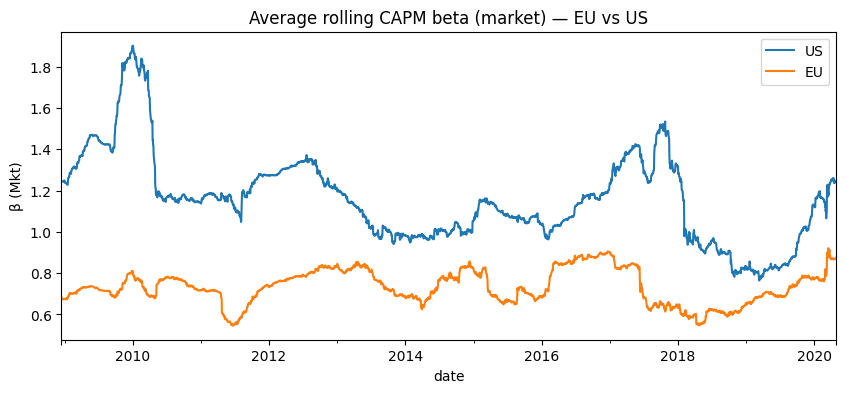

In [ ]:
avg_beta_us = capm_us["beta_Mkt-RF"].groupby(level="date").mean() # avg beta across us banks by date
avg_beta_eu = capm_eu["beta_Mkt-RF"].groupby(level="date").mean() # avg beta across eu banks by date

to_plot = pd.concat([avg_beta_us.rename("US"), avg_beta_eu.rename("EU")], axis=1).dropna(how="all")

ax = to_plot.plot(figsize=(10,4))
ax.set_title("Average rolling CAPM beta (market) — EU vs US")
ax.set_ylabel("β (Mkt)")
ax.legend()
plt.show()


The chart illustrates the evolution of average **market betas** for European and US banks based on a 250-day rolling CAPM estimation. Overall, **European banks exhibit consistently lower betas** than their US counterparts, indicating a lower exposure to systematic market risk. In contrast, US banks display higher and more volatile betas, particularly during periods of financial stress (eg 2008–2009), suggesting that their equity returns have been more sensitive to broad market movements throughout the sample period.

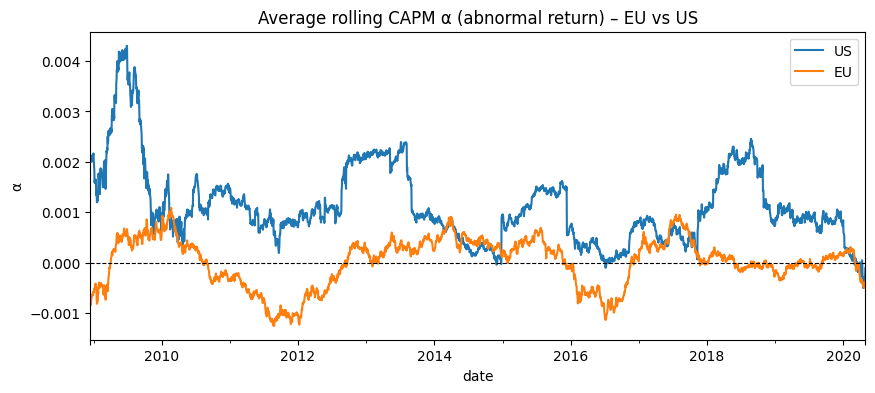

In [ ]:
avg_alpha_us = capm_us["alpha"].groupby(level="date").mean()
avg_alpha_eu = capm_eu["alpha"].groupby(level="date").mean()

pd.concat([ avg_alpha_us.rename("US"),avg_alpha_eu.rename("EU")], axis=1).plot(
    figsize=(10,4), title="Average rolling CAPM α (abnormal return) – EU vs US"
)
plt.ylabel("α")
plt.axhline(0, color="k", linestyle="--", lw=0.8)


Looking instead at the **evolution of the $\alpha$**, which corresponds to the portion of **returns not explained by market movements**, US banks display higher and more volatile alphas. This suggests that US bank returns occasionally exceeded the level predicted by market risk alone.

Conversely, European banks exhibit **lower and often negative alphas**, implying that their returns were more fully explained by market dynamics, with little evidence of consistent excess performance.

However, an interesting pattern besides the series' magnitude, is the fact that EU countries seem to **follow with a lag** the dynamics observed in the US. This patter is consistent with current economic trends, with developments either in a positive and in a negative sense, coming to light before in North America.

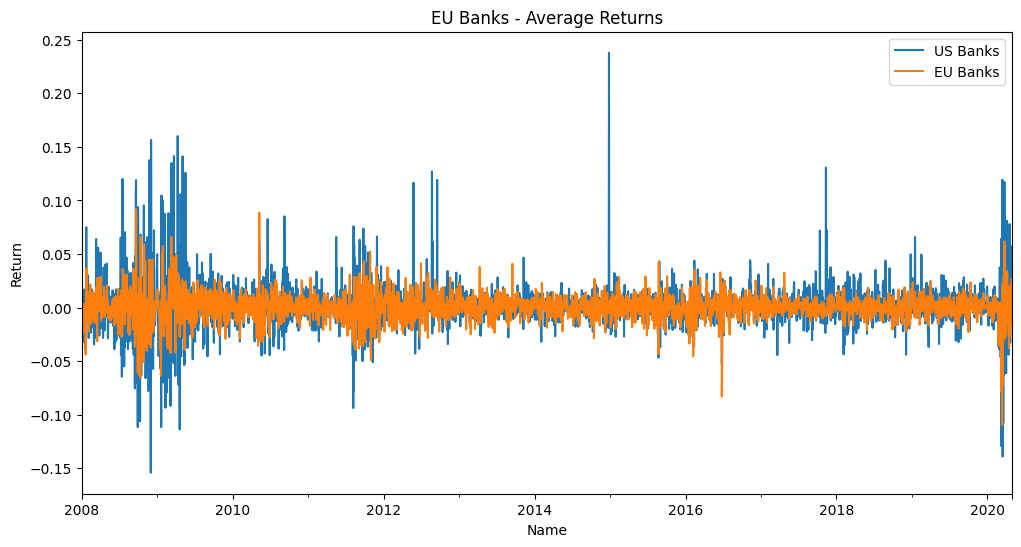

In [ ]:
plt.figure(figsize=(12, 6))
return_us.mean(axis = 1).plot(title='US Banks - Average Returns', figsize=(12, 6))
return_eu.mean(axis = 1).plot(title='EU Banks - Average Returns', figsize=(12, 6))
plt.legend(['US Banks', 'EU Banks'])
plt.ylabel('Return')
plt.show()

Both regions exhibit higher **volatility** during major financial turmoil, notably around the 2008–2009 global financial crisis and the 2020 COVID-19 market shock. Overall, return fluctuations tend to be larger for US banks, indicating greater sensitivity to market-wide events, confirming what we already observed with the betas. In contrast, European banks show relatively smoother return dynamics; this result is **consistent with** their lower average beta and reduced exposure to systematic risk observed in the **CAPM estimates**.


## Fama-French 3-factors

In this section, we extend the basic CAPM framework by incorporating the **Fama–French three-factor model** (Fama and French, 1993). In addition to the market excess return, this specification includes the size (**SMB**) and value (**HML**) factors.

Note: The Fama–French five-factor model would have provided an even richer specification (in the sense of 5 factors included). However, when we tried downloading it from the internet, we were able to find data only covering the period 2020–2025, which falls outside the time span of the NGO campaign dataset (2008–2020). For this reason, we rely on the three-factor version.

In [ ]:
Xeu_ff3 = ff_eu[["Mkt-RF", "SMB", "HML"]]
excess_return_eu = return_eu.sub(ff_eu["RF"], axis=0)

ff3_eu_params = {}

for col in excess_return_eu.columns:
    ff3_eu_params[col] = rolling_ols(excess_return_eu[col], Xeu_ff3)

ff3_eu = pd.concat(ff3_eu_params, axis=0)
ff3_eu.index.names = ["bank", "date"]

ff3_eu.head()

alpha  beta_Mkt-RF  beta_SMB  \
bank                         date                                          
AAREAL BANK - TOT RETURN IND 2008-12-16 -0.000703     1.695160  0.708162   
                             2008-12-17 -0.000925     1.679376  0.683131   
                             2008-12-18 -0.000863     1.676616  0.677381   
                             2008-12-19 -0.000647     1.656636  0.647999   
                             2008-12-22 -0.000245     1.660231  0.675974   

                                         beta_HML  
bank                         date                  
AAREAL BANK - TOT RETURN IND 2008-12-16  1.079595  
                             2008-12-17  1.088700  
                             2008-12-18  1.085514  
                             2008-12-19  1.056688  
                             2008-12-22  1.063185

In [ ]:
Xus_ff3 = ff_us[["Mkt-RF", "SMB", "HML"]]
excess_return_us = return_us.sub(ff_us["RF"], axis=0)

ff3_us_params = {}

for col in excess_return_us.columns:
    ff3_us_params[col] = rolling_ols(excess_return_us[col], Xus_ff3)

ff3_us = pd.concat(ff3_us_params, axis=0)
ff3_us.index.names = ["bank", "date"]

ff3_us.head()

alpha  beta_Mkt-RF  beta_SMB  \
bank                             date                                          
BANK OF AMERICA - TOT RETURN IND 2008-12-16 -0.000130     1.372078 -0.135070   
                                 2008-12-17 -0.000140     1.373386 -0.128351   
                                 2008-12-18 -0.000194     1.373365 -0.125131   
                                 2008-12-19 -0.000300     1.374998 -0.126997   
                                 2008-12-22 -0.000148     1.371694 -0.132157   

                                             beta_HML  
bank                             date                  
BANK OF AMERICA - TOT RETURN IND 2008-12-16  4.226226  
                                 2008-12-17  4.223618  
                                 2008-12-18  4.227066  
                                 2008-12-19  4.223370  
                                 2008-12-22  4.218844

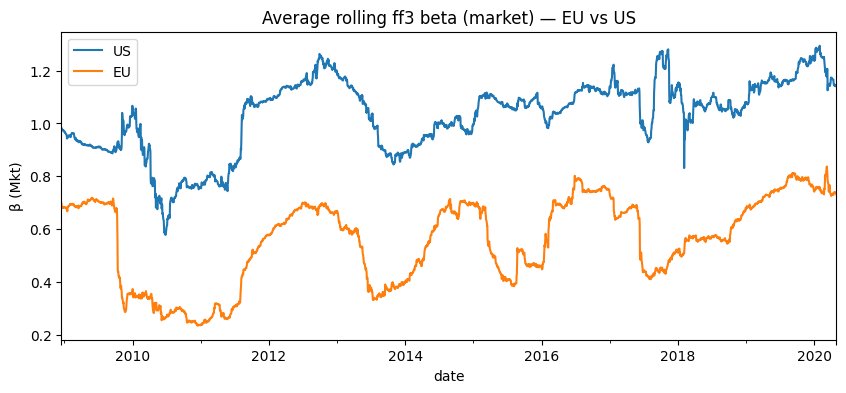

In [ ]:
avg_beta_us_ff3 = ff3_us["beta_Mkt-RF"].groupby(level="date").mean() # avg beta across us banks by date
avg_beta_eu_ff3 = ff3_eu["beta_Mkt-RF"].groupby(level="date").mean() # avg beta across eu banks by date


to_plot = pd.concat([avg_beta_us_ff3.rename("US"),avg_beta_eu_ff3.rename("EU")], axis=1).dropna(how="all")

ax = to_plot.plot(figsize=(10,4))
ax.set_title("Average rolling ff3 beta (market) — EU vs US")
ax.set_ylabel("β (Mkt)")
ax.legend()
plt.show()


As we can see form the y axis, the level of **exposure to the market is lower** compared to the graph displayed before under the CAPM framework. We belive that this might be due to the fact that, if before we only had one factor (the market excess return), here we also accounted for SMB and HML. Therefore, the result above shows the correct exposure to the market, without any confounding component.

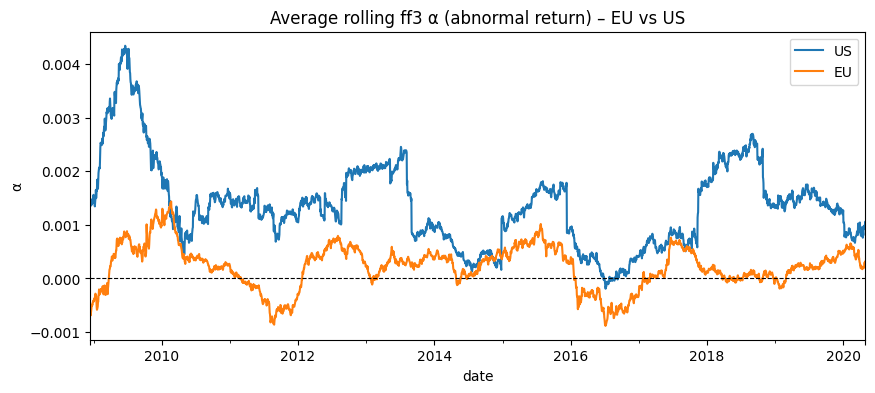

In [ ]:
avg_alpha_us_ff = ff3_us["alpha"].groupby(level="date").mean()
avg_alpha_eu_ff = ff3_eu["alpha"].groupby(level="date").mean()

pd.concat([ avg_alpha_us_ff.rename("US"),avg_alpha_eu_ff.rename("EU")], axis=1).plot(
    figsize=(10,4), title="Average rolling ff3 α (abnormal return) – EU vs US"
)
plt.ylabel("α")
plt.axhline(0, color="k", linestyle="--", lw=0.8)


As before, levels of $alpha$ are clustered **around zero**, with US banks exhibiting slightly higher alphas. However, when including the additional SMB (size) and HML (value) factors from the Fama–French three-factor model, the average abnormal returns (α) for both US and European banks move slightly closer to zero compared with the CAPM estimates. This indicates that **part of the apparent excess returns captured under CAPM** can be explained by exposure to size and value effects.

# **Task 5**: Compute CARs

### Cleaning and merging

In this section we clean and merge the NGO Sigwatch dataset (`banks_ngo`) with the returns datasets. We first tidy the Sigwatch dataset to keep the columns that we deem more relevant to create the `events` dataset.

In [ ]:
cols = []
for col in banks_ngo.columns:
  cols.append(col)

print(cols)

['uid_archive', 'date', 'company_code', 'company', 'company_type', 'company_parent_code', 'company_parent', 'company_parent_country', 'sentiment', 'prominence', 'partnership', 'issue_code1', 'issue_name1', 'issue_code2', 'issue_name2', 'issue_code3', 'issue_name3', 'active_country_code1', 'active_country1', 'active_country_code2', 'active_country2', 'active_country_code3', 'active_country3', 'active_country_code4', 'active_country4', 'active_country_code5', 'active_country5', 'active_country_code6', 'active_country6', 'target_country_code1', 'target_country1', 'target_country_code2', 'target_country2', 'target_country_code3', 'target_country3', 'target_country_code4', 'target_country4', 'target_country_code5', 'target_country5', 'target_country_code6', 'target_country6', 'ngo_code1', 'ngo_name1', 'ngo_power1', 'ngo_country_code1', 'ngo_country1', 'ngo_code2', 'ngo_name2', 'ngo_power2', 'ngo_country_code2', 'ngo_country2', 'ngo_code3', 'ngo_name3', 'ngo_power3', 'ngo_country_code3', 'ng

In [ ]:
# creating a simpler and cleaner version of banks_ngo

cols_to_keep = ['date','company', 'company_parent_country', 'sentiment','prominence', 'report',
                                 'issue_name1', 'issue_name2', 'issue_name3',
                                 'ngo_name1','ngo_power1',
                                 'ngo_name2','ngo_power2',
                                 'ngo_name3','ngo_power3',
                                 'ngo_name4','ngo_power4',
                                 'ngo_name5','ngo_power5']

events = (banks_ngo.loc[:, cols_to_keep].copy())

# chekc all dates are datetime
events["date"] = pd.to_datetime(events["date"], errors="coerce")
events = events.dropna(subset=["date"])


# keep one row per unique company, event_date, report combination
events = (events.drop_duplicates(subset=["company", "date", "report"]).reset_index(drop=True))

print("Events:", len(events))
events.head(3)

Events: 2821


,date,company,company_parent_country,sentiment,prominence,report,issue_name1,issue_name2,issue_name3,ngo_name1,ngo_power1,ngo_name2,ngo_power2,ngo_name3,ngo_power3,ngo_name4,ngo_power4,ngo_name5,ngo_power5
0,2010-02-12,pinnacle financial ptns.,US,1,2,"In the US, the environmentalist investor coali...",Water footprint & efficiency,Water use in food processing,,Ceres/INCR,2.0,,NaN,,NaN,,NaN,,NaN
1,2010-02-26,bnp paribas,France,-1,2,"In Indonesia, a coalition of NGOs including Ku...",Mining - environmental impact,Mining - social impact,,Amis de la Terre France / FoE France,2.5,BankTrack,2.5,WALHI / FoE Indonesia,2.5,Mineral Policy Institute MPI,1.0,Robin Wood,1.0
2,2010-04-05,bnp paribas,France,-2,2,"In Belgium, Netwerk Vlaanderen ranked ING, Deu...",CSR/ESG standards for financial institutions,Financial institutions funding arms industry,,FairFin (previously Netwerk Vlaanderen),1.0,,NaN,,NaN,,NaN,,NaN


To be able to merge the returns (`return_us` and `return_eu`) we clean their bank names, to try and match them with the ones in the `events` dataset.

The process starts with cleaning the returns headers, which correspond to the names of the banks, and then we create a manual mapping in order to make all corresponding banks have the same exact name.

In [ ]:
def clean_return_headers(df):
    cols = (pd.Index(df.columns)
            .str.replace(r"\s*-\s*TOT RETURN IND$", "", regex=True)  # strip DS suffix
            .str.replace(r"\s+", " ", regex=True)
            #.str.replace(r'[^a-z0-9]', '', regex=True)
            .str.strip()
            .str.lower())
    df.columns = cols
    return df



return_us = clean_return_headers(return_us)
return_eu = clean_return_headers(return_eu)

In [ ]:
# making sure the dates are in datetime format

return_us.index = pd.to_datetime(return_us.index, errors="coerce")
return_us.index.name = "date"
return_eu.index = pd.to_datetime(return_eu.index, errors="coerce")
return_eu.index.name = "date"

In [ ]:
bank_list = sorted(list(banks_ngo['company'].unique()))
print(bank_list)

['abn amro bank', 'ace cash express', 'admiral group', 'advent international corporation', 'aegon', 'aetna', 'aflac', 'aib group', 'alliance trust', 'allianz group / allianz se', 'ally financial', 'american express company', 'american international group (aig)', 'ares management', 'asr nederland', 'axis capital', 'banca generali', 'banco de sabadell', 'banco santander', 'bank of america', 'bank of ireland group', 'bank of new york mellon', 'bankia', 'banque de savoie', 'barclays', 'bbv.argentaria', 'berkshire bank', 'berner kantonalbank', 'bnp paribas', 'caixabank', 'citigroup', 'citizens financial group', 'comerica', 'commerzbank', 'credit agricole', 'delta lloyd group', 'deutsche bank', 'discover financial svs.', 'dnb', 'erste group bank', 'fifth third bancorp', 'goldman sachs group, inc.', 'hsbc holdings', 'huntington bcsh.', 'ing groep', 'intesa sanpaolo', 'jp morgan chase', 'kbc group', 'keycorp', 'lcl', 'lehman brothers holdings inc.', 'liberbank', 'lloyds banking group', 'luzern

In [ ]:
banks = [
    'abn amro bank','ace cash express','admiral group','advent international corporation','aegon','aetna','aflac',
    'aib group','alliance trust','allianz group / allianz se','ally financial','american express company',
    'american international group (aig)','ares management','asr nederland','axis capital','banca generali',
    'banco de sabadell','banco santander','bank of america','bank of ireland group','bank of new york mellon',
    'bankia','banque de savoie','barclays','bbv.argentaria','berkshire bank','berner kantonalbank','bnp paribas',
    'caixabank','citigroup','citizens financial group','comerica','commerzbank','credit agricole','delta lloyd group',
    'deutsche bank','discover financial svs.','dnb','erste group bank','fifth third bancorp',
    'goldman sachs group, inc.','hsbc holdings','huntington bcsh.','ing groep','intesa sanpaolo','jp morgan chase',
    'kbc group','keycorp','lcl','lehman brothers holdings inc.','liberbank','lloyds banking group',
    'luzerner kantonalbank','m&t bank','mastercard','mediobanca','metro bank','natixis','nibc holding','nordea bank',
    'permanent tsb ghg.','pinnacle financial ptns.','pnc finl.svs.gp.','raiffeisen zentralbank osterreich',
    'royal bank of sctl.gp.','saga group','schweizerische nat.bk.','societe generale','sparebank 1 sr-bank',
    'standard chartered','svb financial group','swedbank a','synovus financial','tcf financial','umweltbank',
    'unicaja banco','unicredit','us bancorp','virgin money uk','volksbank ag','wells fargo & co','zions bancorp.'
]

# manual mapping
alias = {

    "allianz": "allianz group / allianz se",
    "american express": "american express company",
    "american intl.gp.": "american international group (aig)",
    "ares management a": "ares management",
    "axis capital hdg.": "axis capital",
    "goldman sachs gp.": "goldman sachs group, inc.",
    "jp morgan chase & co.": "jp morgan chase",
    "mediobanca bc.fin": "mediobanca",
    "mersen (ex lcl)": "lcl",
    "berkshire hills bancorp": "berkshire bank",
    "banque de savoie dead - 01/04/10": "banque de savoie",
    "ace cash express (ber) dead - 10/10/06": "ace cash express",
    "delta lloyd group dead - dead 01/06/17": "delta lloyd group",
    "lehman bros.hdg.cap.tst. iii pf.sr.k": "lehman brothers holdings inc.",
    "kbc ancora": "kbc group",
    "hsbc bank malta": "hsbc holdings",
    "raiffeisen bank intl.": "raiffeisen zentralbank osterreich",
}

In [ ]:
def apply_alias(df, alias_dict):
    df = df.copy()
    cols = [alias_dict.get(col, col) for col in df.columns]
    df.columns = cols

    df = df.groupby(level=0, axis=1).first()
    return df

return_us = apply_alias(return_us, alias)
return_eu = apply_alias(return_eu, alias)

/tmp/ipython-input-977621676.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df = df.groupby(level=0, axis=1).first()
/tmp/ipython-input-977621676.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df = df.groupby(level=0, axis=1).first()


In [ ]:
# keeping only the banks that are in the NGO campaigns
return_us = return_us[[col for col in return_us.columns if col in banks]]
return_eu = return_eu[[col for col in return_eu.columns if col in banks]]

In [ ]:
all_returns = pd.concat([return_eu, return_us], axis=1)
all_returns.head()

,admiral group,aegon,aib group,alliance trust,allianz group / allianz se,banca generali,banco de sabadell,banco santander,bank of ireland group,banque de savoie,...,m&t bank,mastercard,pinnacle financial ptns.,pnc finl.svs.gp.,svb financial group,synovus financial,tcf financial,us bancorp,wells fargo & co,zions bancorp.
date,,,,,,,,,,,,,,,,,,,,,
2008-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-02,-0.004561,-0.009099,-0.004986,0.003181,-0.017896,-0.014534,-0.013490,-0.013525,0.018686,0.0,...,-0.019492,-0.002403,-0.037764,-0.014014,-0.009722,0.025621,-0.041610,-0.017643,-0.036105,-0.029985
2008-01-03,0.004582,-0.006678,-0.008155,0.006930,-0.005638,-0.033974,-0.024604,-0.009592,0.002163,0.0,...,-0.014754,-0.011935,-0.011457,-0.011278,-0.011220,0.025000,-0.015351,-0.027261,-0.019931,-0.020092
2008-01-04,-0.029103,-0.019327,0.002449,-0.022024,-0.019777,-0.044984,-0.029470,-0.014533,-0.004381,0.0,...,-0.037436,-0.051530,-0.047972,-0.022655,-0.026544,-0.016259,-0.020046,-0.029344,-0.036114,-0.044615
2008-01-07,-0.010290,-0.002571,-0.022081,0.000704,-0.012628,-0.034399,-0.025991,-0.006319,-0.009616,0.0,...,0.008570,-0.003366,-0.003900,0.014707,0.006869,0.023874,0.035458,0.009172,0.006911,0.020755


we reformat into a long dataframe in order to match the shape of the events dataset and be ble to merge them together

In [ ]:
returns_long = (
    all_returns
    .stack()
    .rename("ret")
    .reset_index()
)
returns_long.columns = ["date", "company", "ret"]

In [ ]:
returns_long

,date,company,ret
0,2008-01-02,admiral group,-0.004561
1,2008-01-02,aegon,-0.009099
2,2008-01-02,aib group,-0.004986
3,2008-01-02,alliance trust,0.003181
4,2008-01-02,allianz group / allianz se,-0.017896
...,...,...,...
218615,2020-04-28,synovus financial,0.068548
218616,2020-04-28,tcf financial,0.107603
218617,2020-04-28,us bancorp,0.021460
218618,2020-04-28,wells fargo & co,0.016191


At this point we have:
- `events`: one row per campaign (company, event_date, sentiment…)

- `returns_long`: daily returns per (company, date)

we merge them to create a new version of the events dataset with the daily returns added for each company

In [ ]:
events = events.merge(
    returns_long, left_on=["company","date"],
    right_on=["company","date",],
    how="left")

In [ ]:
events.head()

,date,company,company_parent_country,sentiment,prominence,report,issue_name1,issue_name2,issue_name3,ngo_name1,ngo_power1,ngo_name2,ngo_power2,ngo_name3,ngo_power3,ngo_name4,ngo_power4,ngo_name5,ngo_power5,ret
0,2010-02-12,pinnacle financial ptns.,US,1,2,"In the US, the environmentalist investor coali...",Water footprint & efficiency,Water use in food processing,,Ceres/INCR,2.0,,NaN,,NaN,,NaN,,NaN,0.021455
1,2010-02-26,bnp paribas,France,-1,2,"In Indonesia, a coalition of NGOs including Ku...",Mining - environmental impact,Mining - social impact,,Amis de la Terre France / FoE France,2.5,BankTrack,2.5,WALHI / FoE Indonesia,2.5,Mineral Policy Institute MPI,1.0,Robin Wood,1.0,0.031442
2,2010-04-05,bnp paribas,France,-2,2,"In Belgium, Netwerk Vlaanderen ranked ING, Deu...",CSR/ESG standards for financial institutions,Financial institutions funding arms industry,,FairFin (previously Netwerk Vlaanderen),1.0,,NaN,,NaN,,NaN,,NaN,0.000000
3,2010-04-05,citigroup,US,-2,2,"In Belgium, Netwerk Vlaanderen ranked ING, Deu...",CSR/ESG standards for financial institutions,Financial institutions funding arms industry,,FairFin (previously Netwerk Vlaanderen),1.0,,NaN,,NaN,,NaN,,NaN,0.019146
4,2010-04-05,deutsche bank,Germany,-2,2,"In Belgium, Netwerk Vlaanderen ranked ING, Deu...",CSR/ESG standards for financial institutions,Financial institutions funding arms industry,,FairFin (previously Netwerk Vlaanderen),1.0,,NaN,,NaN,,NaN,,NaN,0.000000


In [ ]:
events["date"] = pd.to_datetime(events["date"])
ff_us.index = pd.to_datetime(ff_us.index, errors="raise")
ff_eu.index = pd.to_datetime(ff_eu.index, errors="raise")

We create a new column in the `events` dataframe that maps to 'EU' or 'US' based on the country of the parent company of the bank. This column will be used later on to merge the location specific `ff_us` and `ff_eu` datasets

In [ ]:
events["region"] = np.where(events["company_parent_country"].eq("US"), "US", "EU")

# mapping region per company
region_map = (events.groupby("company")["region"]
                   .agg(lambda s: s.mode().iat[0] if len(s.mode()) else s.iloc[0])
                   .to_dict())

In this section below, we create the **event window dataset** which is the collection of daily stock returns surrounding each NGO campaign event.

We want to analyze how a bank's stock price reacts to an NGO campaign.
To do this, we construct for each event a time window of returns covering **10 trading days before and 10 after** the event  (`t_rel = 0` marks the trading day when the event becomes observable to the market).

 Creates the `windows_df`dataframe containing:
 - `date`: trading dates
 - `event_date`: event-aligned trading day (t₀)
 - `company`: company name
 - `t_rel`: relative day around the event (−10 … +10)
 - `ret`: observed daily return

And the other columns that were included in the events dataset.

In [ ]:
def get_event_window(company, event_date, window=10):
    if company not in all_returns.columns:
        return None
    s = all_returns[company].dropna()
    idx = s.index

    pos = idx.searchsorted(pd.Timestamp(event_date))
    if pos >= len(idx):
        return None
    t0 = idx[pos]
    start = max(0, pos - window)
    end   = min(len(idx), pos + window + 1)

    dates = idx[start:end]
    t_rel = np.arange(start - pos, end - pos)
    out = pd.DataFrame({
        "date": dates, "event_date": t0, "company": company,
        "t_rel": t_rel, "ret": s.loc[dates].values
    })
    return out

In [ ]:
event_windows = []
for _, ev in events.iterrows():
    dfw = get_event_window(ev["company"], ev["date"], window=10)
    if dfw is not None:
        # attach event attributes you want downstream
        dfw["company_parent_country"] = ev["company_parent_country"]
        dfw["sentiment"] = ev["sentiment"]
        dfw["prominence"] = ev["prominence"]
        dfw["issue_name1"] = ev["issue_name1"]
        dfw["issue_name2"] = ev["issue_name2"]
        dfw["issue_name3"] = ev["issue_name3"]
        dfw["ngo_name1"] = ev["ngo_name1"]
        dfw["ngo_power1"] = ev["ngo_power1"]
        dfw["ngo_name2"] = ev["ngo_name2"]
        dfw["ngo_power2"] = ev["ngo_power2"]
        dfw["ngo_name3"] = ev["ngo_name3"]
        dfw["ngo_power3"] = ev["ngo_power3"]
        dfw["ngo_name4"] = ev["ngo_name4"]
        dfw["ngo_power4"] = ev["ngo_power4"]
        dfw["ngo_name5"] = ev["ngo_name5"]
        dfw["ngo_power5"] = ev["ngo_power5"]
        dfw["region"] = region_map[ev["company"]]

        event_windows.append(dfw)

windows_df = pd.concat(event_windows, ignore_index=True)

## Merging with Fama-French factors

In the section below we clean the company names in the `ff3_us` and `ff3_eu` datasets in order to be able to merge them with the `windows_df` dataset. This process is very similar to what was done above for returns.

In [ ]:
def clean_ff(df):
    out = df.copy()

    banks = (out.index.get_level_values('bank').astype(str)
             .str.replace(r'\s*-\s*TOT RETURN IND$', '', regex=True)
             .str.replace(r'\s+', ' ', regex=True)
             .str.strip()
             .str.lower())

    dates = pd.to_datetime(out.index.get_level_values('date'))

    out.index = pd.MultiIndex.from_arrays([banks, dates], names=['company','date'])

    return out[['alpha','beta_Mkt-RF', 'beta_SMB', 'beta_HML']].sort_index()

In [ ]:
ff_us_clean = clean_ff(ff3_us)
ff_eu_clean = clean_ff(ff3_eu)

In [ ]:
ff_us_clean = ff_us_clean.reset_index().sort_values(["company","date"])
ff_eu_clean = ff_eu_clean.reset_index().sort_values(["company","date"])

In [ ]:
def apply_alias_to_series(series, alias_dict):
    """
    Apply alias mapping to a pandas Series (e.g., 'company' column in capm_flat)
    and collapse variants to canonical names.
    """
    s = series.str.lower().str.strip()
    s = s.replace(alias_dict)  # use alias mapping
    return s

In [ ]:
ff_us_clean["company"] = apply_alias_to_series(ff_us_clean["company"], alias)
ff_eu_clean["company"] = apply_alias_to_series(ff_eu_clean["company"], alias)

In [ ]:
ff_us_clean = ff_us_clean[ff_us_clean["company"].isin(banks)]
ff_eu_clean = ff_eu_clean[ff_eu_clean["company"].isin(banks)]

In [ ]:
ff_eu_clean.head()

,company,date,alpha,beta_Mkt-RF,beta_SMB,beta_HML
2966,admiral group,2008-12-16,0.000256,0.429250,-0.927445,-0.226464
2967,admiral group,2008-12-17,-0.000009,0.410458,-0.958565,-0.216973
2968,admiral group,2008-12-18,0.000153,0.396829,-0.985172,-0.239827
2969,admiral group,2008-12-19,0.000305,0.383537,-1.004246,-0.257243
2970,admiral group,2008-12-22,0.000308,0.374882,-1.028749,-0.255332


In [ ]:
windows_df.sort_values(by = ['company','date']).head()

,date,event_date,company,t_rel,ret,company_parent_country,sentiment,prominence,issue_name1,issue_name2,...,ngo_power1,ngo_name2,ngo_power2,ngo_name3,ngo_power3,ngo_name4,ngo_power4,ngo_name5,ngo_power5,region
24402,2014-10-09,2014-10-23,ace cash express,-10,0.0,Switzerland,1,2,Climate change - impact on health,Climate change - risk to business,...,2.0,,NaN,,NaN,,NaN,,NaN,EU
24403,2014-10-10,2014-10-23,ace cash express,-9,0.0,Switzerland,1,2,Climate change - impact on health,Climate change - risk to business,...,2.0,,NaN,,NaN,,NaN,,NaN,EU
24404,2014-10-13,2014-10-23,ace cash express,-8,0.0,Switzerland,1,2,Climate change - impact on health,Climate change - risk to business,...,2.0,,NaN,,NaN,,NaN,,NaN,EU
24405,2014-10-14,2014-10-23,ace cash express,-7,0.0,Switzerland,1,2,Climate change - impact on health,Climate change - risk to business,...,2.0,,NaN,,NaN,,NaN,,NaN,EU
24406,2014-10-15,2014-10-23,ace cash express,-6,0.0,Switzerland,1,2,Climate change - impact on health,Climate change - risk to business,...,2.0,,NaN,,NaN,,NaN,,NaN,EU


In this section, we align the event windows with the **period of available beta estimates** for each company, ensuring that we only analyze events for which reliable Fama–French model parameters (α and βs) are available.

Each company’s factors (`alpha`, `beta_Mkt-RF`, `beta_SMB`, `beta_HML`)
are estimated from rolling regressions (`ff_us_clean`, `ff_eu_clean`)
that only exist within a limited date range: the period covered by the available historical returns.

If we include events that fall outside this range, their abnormal returns (AR)
would rely on missing or extrapolated betas, leading to biased or meaningless CARs.

We merge the minimum and maximum dates of available beta estimates
   (`min_beta`, `max_beta`) with each company's event window in `windows_df`.

We only keep events where the **event date (`event_date`)** lies inside the company’s beta range. This ensures that betas are valid at the time of the event.

We then merge back only the valid `(company, event_date)` pairs into the full window data.

In [ ]:
us_rng = (ff_us_clean.groupby('company')['date']
          .agg(min_beta='min', max_beta='max')
          .reset_index()
          .assign(region='US'))

eu_rng = (ff_eu_clean.groupby('company')['date']
          .agg(min_beta='min', max_beta='max')
          .reset_index()
          .assign(region='EU'))

beta_ranges = pd.concat([us_rng, eu_rng], ignore_index=True)

In [ ]:
w = windows_df.merge(beta_ranges, on=['company','region'], how='left')

# keep if event_date is inside the company's beta range
valid_events = (
    w.query("event_date >= min_beta and event_date <= max_beta")
      [["company", "event_date"]]
      .drop_duplicates()
)
windows_df_clip = (
    w.merge(valid_events, on=["company","event_date"], how="inner")
      .drop(columns=["min_beta","max_beta"])
)

In [ ]:
print("rows windows before:", len(windows_df))
print("rows windows later :", len(windows_df_clip))

rows windows before: 55062
rows windows later : 51513


In this step, we **merge the event windows (`windows_df`)** with the company-level **Fama-French regression outputs** (`ff_us_clean` and `ff_eu_clean`).

Each row in `windows_df` represents a specific company-day pair within the event window.  
By merging with `ff_us_clean` (for U.S. firms) and `ff_eu_clean` (for European firms), we attach the estimated **alpha** and **beta coefficients** (`β_Mkt-RF`, `β_SMB`, `β_HML`) corresponding to that company and date.

After attaching each company's **estimated alpha and betas**, we merge in the **daily Fama-French factor values**
(`Mkt-RF`, `SMB`, `HML`, and `RF`) to align market conditions
with each observation in the event windows.

The resulting `merged` DataFrame now contains:
- daily stock returns for each company-event window,  
- company-level α and βs,  
- and the corresponding daily market factors.

In [ ]:
windows_df = windows_df_clip

In [ ]:
# we split the df into two region specific ones
windows_us = windows_df[windows_df['region'] == 'US']
windows_non_us = windows_df[windows_df['region'] != 'US']

In [ ]:
merged_us = pd.merge(
    windows_us,
    ff_us_clean,
    on=["company", "date"],
    how="left"
)

merged_non_us = pd.merge(
    windows_non_us,
    ff_eu_clean,
    on=["company", "date"],
    how="left"
)

In [ ]:
merged_us2 = pd.merge(
    merged_us,
    ff_us,
    on= "date",
    how="left"
)

merged_non_us2 = pd.merge(
    merged_non_us,
    ff_eu,
    on= "date",
    how="left"
)

In [ ]:
merged = pd.concat([merged_us2, merged_non_us2], ignore_index=True)

In [ ]:
merged.head()

,date,event_date,company,t_rel,ret,company_parent_country,sentiment,prominence,issue_name1,issue_name2,...,ngo_power5,region,alpha,beta_Mkt-RF,beta_SMB,beta_HML,Mkt-RF,SMB,HML,RF
0,2010-01-29,2010-02-12,pinnacle financial ptns.,-10,-0.028268,US,1,2,Water footprint & efficiency,Water use in food processing,...,NaN,US,-0.003207,0.903127,0.878677,1.191490,-0.0107,0.0004,-0.0031,0.0
1,2010-02-01,2010-02-12,pinnacle financial ptns.,-9,0.004618,US,1,2,Water footprint & efficiency,Water use in food processing,...,NaN,US,-0.003281,0.900922,0.884386,1.187297,0.0153,-0.0009,0.0083,0.0
2,2010-02-02,2010-02-12,pinnacle financial ptns.,-8,0.012508,US,1,2,Water footprint & efficiency,Water use in food processing,...,NaN,US,-0.003321,0.913678,0.861960,1.180917,0.0123,-0.0035,0.0046,0.0
3,2010-02-03,2010-02-12,pinnacle financial ptns.,-7,-0.073474,US,1,2,Water footprint & efficiency,Water use in food processing,...,NaN,US,-0.003729,0.889840,0.910907,1.253864,-0.0049,0.0004,-0.0057,0.0
4,2010-02-04,2010-02-12,pinnacle financial ptns.,-6,-0.054033,US,1,2,Water footprint & efficiency,Water use in food processing,...,NaN,US,-0.003538,0.911455,0.885007,1.193776,-0.0315,-0.0036,-0.0068,0.0


## CAR calculation

In this section, we calculate the **Abnormal Returns (AR)** and later the **Cumulative Abnormal Returns (CAR)** for each company-event-day observation.

Here the expected returns are calculated using the **Fama-French 3-Factor Model parameters estimated 50 trading days before each event**.  

$$
E[R_{i,t} - R_{f,t}] = \alpha_{i,t-50} +
\beta_{i,M,t-50}(MKT_t - R_{f,t}) +
\beta_{i,S,t-50}SMB_t +
\beta_{i,H,t-50}HML_t
$$

where:
- $\alpha_{i,t-50}$, $\beta_{i,M,t-50}$, $\beta_{i,S,t-50}$, $\beta_{i,H,t-50}$
  are the parameters estimated **50 days before the event date**;
- $R_{i,t}$ is the observed stock return for company *i* on day *t*;  
- $R_{f,t}$ is the daily risk-free rate;  
- $MKT_t - R_{f,t}, SMB_t, HML_t$ are the Fama-French market, size, and value factors.

The **Abnormal Return (AR)** measures how much the realized excess return deviates from the model's expected excess return:

$$
AR_{i,t} = (R_{i,t} - R_{f,t}) - E[R_{i,t} - R_{f,t}]
$$

This means we compare the actual performance of a firm's stock
to what the model predicts, given its historical sensitivity to market factors
estimated **up to 50 trading days before the event**.

In [ ]:
def params_at_gap_for_pairs(pairs_df, params_df, gap=50,
                            cols=("alpha","beta_Mkt-RF","beta_SMB","beta_HML")):

    need = {"company","date", *cols}
    missing = need - set(params_df.columns)
    if missing:
        raise KeyError(f"params_df mancano colonne: {sorted(missing)}")

    params = params_df.copy()
    params["date"] = pd.to_datetime(params["date"], errors="coerce")
    for c in cols:
        params[c] = pd.to_numeric(params[c], errors="coerce")

    params = params.sort_values(["company","date"]).reset_index(drop=True)

    out_rows = []
    grp = {k: v for k, v in params.groupby("company", sort=False)}

    for company, ev in pairs_df[["company","event_date"]].itertuples(index=False):
        if company not in grp:
            continue
        sub = grp[company]

        ev_ts = pd.Timestamp(ev)
        pos = np.searchsorted(sub["date"].values.astype("datetime64[ns]"),
                              np.datetime64(ev_ts, "ns"), side="left")

        i_est = pos - gap
        if i_est < 0 or i_est >= len(sub): #not enough history
            continue

        t_est = sub.iloc[i_est]["date"]

        row = {"company": company, "event_date": ev_ts, "t_est": t_est}
        for c in cols:
            row[f"{c}_tminus50"] = float(sub.iloc[i_est][c]) if pd.notna(sub.iloc[i_est][c]) else np.nan

        out_rows.append(row)

    return pd.DataFrame(out_rows)


In [ ]:
pairs = merged[["company","event_date"]].drop_duplicates().copy()
pairs["event_date"] = pd.to_datetime(pairs["event_date"], errors="coerce")

lookup_us = params_at_gap_for_pairs(pairs, ff_us_clean, gap=50)
lookup_eu = params_at_gap_for_pairs(pairs, ff_eu_clean, gap=50)
params_tminus50 = pd.concat([lookup_us, lookup_eu], ignore_index=True)

merged2 = merged.merge(params_tminus50, on=["company","event_date"], how="left")


In [ ]:
ER = merged2["alpha_tminus50"] + merged2["beta_Mkt-RF_tminus50"] * merged2["Mkt-RF"]

m = merged2[["beta_SMB_tminus50","SMB"]].notna().all(axis=1)
ER.loc[m] = ER.loc[m] + merged2.loc[m,"beta_SMB_tminus50"] * merged2.loc[m,"SMB"]

m = merged2[["beta_HML_tminus50","HML"]].notna().all(axis=1)
ER.loc[m] = ER.loc[m] + merged2.loc[m,"beta_HML_tminus50"] * merged2.loc[m,"HML"]

merged2["ER_expected"] = ER
merged2["AR"] = (merged2["ret"] - merged2["RF"]) - merged2["ER_expected"]

In [ ]:
merged2.head()

,date,event_date,company,t_rel,ret,company_parent_country,sentiment,prominence,issue_name1,issue_name2,...,SMB,HML,RF,t_est,alpha_tminus50,beta_Mkt-RF_tminus50,beta_SMB_tminus50,beta_HML_tminus50,ER_expected,AR
0,2010-01-29,2010-02-12,pinnacle financial ptns.,-10,-0.028268,US,1,2,Water footprint & efficiency,Water use in food processing,...,0.0004,-0.0031,0.0,2009-12-04,-0.003777,1.016814,0.6666,1.242605,-0.018242,-0.010025
1,2010-02-01,2010-02-12,pinnacle financial ptns.,-9,0.004618,US,1,2,Water footprint & efficiency,Water use in food processing,...,-0.0009,0.0083,0.0,2009-12-04,-0.003777,1.016814,0.6666,1.242605,0.021494,-0.016876
2,2010-02-02,2010-02-12,pinnacle financial ptns.,-8,0.012508,US,1,2,Water footprint & efficiency,Water use in food processing,...,-0.0035,0.0046,0.0,2009-12-04,-0.003777,1.016814,0.6666,1.242605,0.012113,0.000396
3,2010-02-03,2010-02-12,pinnacle financial ptns.,-7,-0.073474,US,1,2,Water footprint & efficiency,Water use in food processing,...,0.0004,-0.0057,0.0,2009-12-04,-0.003777,1.016814,0.6666,1.242605,-0.015576,-0.057898
4,2010-02-04,2010-02-12,pinnacle financial ptns.,-6,-0.054033,US,1,2,Water footprint & efficiency,Water use in food processing,...,-0.0036,-0.0068,0.0,2009-12-04,-0.003777,1.016814,0.6666,1.242605,-0.046656,-0.007377


After computing the **daily Abnormal Returns (AR)** for each company and each trading day
within the event window, we now measure the **total effect** that the NGO campaign
had on the firm's stock price.


While ARs capture the **daily reaction**, the **Cumulative Abnormal Return (CAR)**
aggregates these reactions over the full event window, in our case, 10 trading days before and 10 after the event date.

$$
CAR_{i,[-10,+10]} = \sum_{t=-10}^{+10} AR_{i,t}
$$

This gives the overall market-adjusted price impact associated with each event.

In [ ]:
CARs = (
    merged2
    .query("t_rel >= -10 and t_rel <= 10")
    .groupby(["company", "event_date"], as_index=False)["AR"]
    .sum()
    .rename(columns={"AR": "CAR"})
)

In [ ]:
CARs.rename(columns={"event_date": "date"}, inplace=True)

In [ ]:
events_with_car = events.merge(CARs, on=["company","date"], how="left")

In [ ]:
events_with_car.head()

,date,company,company_parent_country,sentiment,prominence,report,issue_name1,issue_name2,issue_name3,ngo_name1,...,ngo_power2,ngo_name3,ngo_power3,ngo_name4,ngo_power4,ngo_name5,ngo_power5,ret,region,CAR
0,2010-02-12,pinnacle financial ptns.,US,1,2,"In the US, the environmentalist investor coali...",Water footprint & efficiency,Water use in food processing,,Ceres/INCR,...,NaN,,NaN,,NaN,,NaN,0.021455,US,-0.000192
1,2010-02-26,bnp paribas,France,-1,2,"In Indonesia, a coalition of NGOs including Ku...",Mining - environmental impact,Mining - social impact,,Amis de la Terre France / FoE France,...,2.5,WALHI / FoE Indonesia,2.5,Mineral Policy Institute MPI,1.0,Robin Wood,1.0,0.031442,EU,-0.047487
2,2010-04-05,bnp paribas,France,-2,2,"In Belgium, Netwerk Vlaanderen ranked ING, Deu...",CSR/ESG standards for financial institutions,Financial institutions funding arms industry,,FairFin (previously Netwerk Vlaanderen),...,NaN,,NaN,,NaN,,NaN,0.000000,EU,-0.110335
3,2010-04-05,citigroup,US,-2,2,"In Belgium, Netwerk Vlaanderen ranked ING, Deu...",CSR/ESG standards for financial institutions,Financial institutions funding arms industry,,FairFin (previously Netwerk Vlaanderen),...,NaN,,NaN,,NaN,,NaN,0.019146,US,0.156770
4,2010-04-05,deutsche bank,Germany,-2,2,"In Belgium, Netwerk Vlaanderen ranked ING, Deu...",CSR/ESG standards for financial institutions,Financial institutions funding arms industry,,FairFin (previously Netwerk Vlaanderen),...,NaN,,NaN,,NaN,,NaN,0.000000,EU,-0.089638


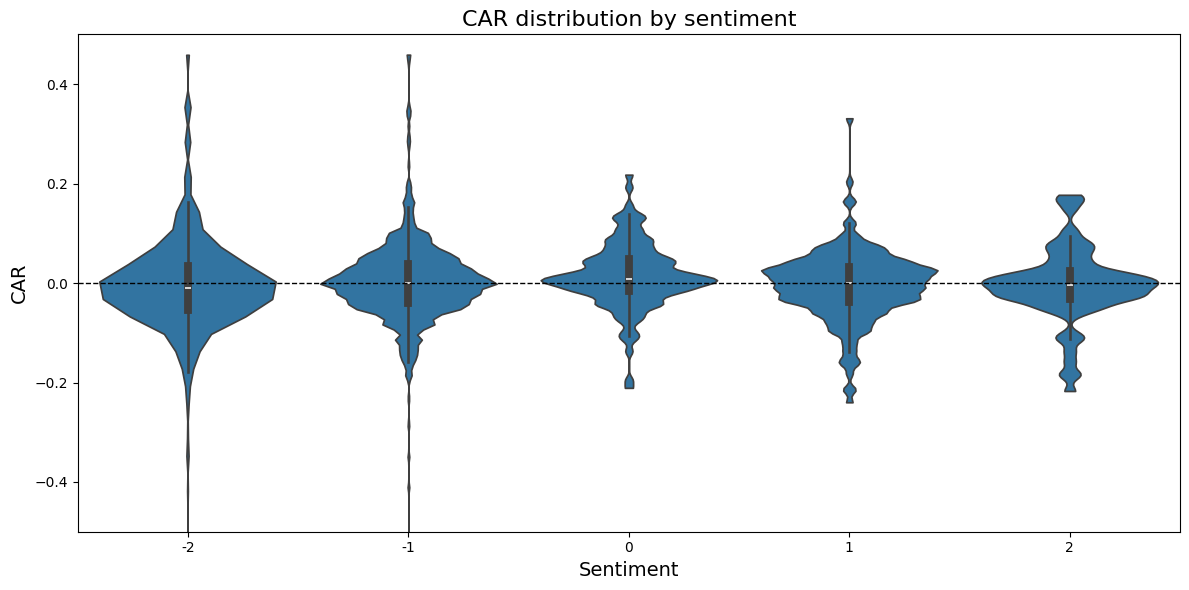

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=events_with_car,
    x='sentiment',
    y='CAR',
    bw_adjust=0.3,
    cut=0,
    inner='box',
    density_norm='width',
    ax=ax
)

ax.set_ylim(-0.5, 0.5)
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_title("CAR distribution by sentiment", fontsize=16)
ax.set_xlabel("Sentiment", fontsize=14)
ax.set_ylabel("CAR", fontsize=14)

plt.tight_layout()
plt.show()

This violin plot shows the distribution of **Cumulative Abnormal Returns (CAR)** across different sentiment levels of NGO campaign events.  
Each violin represents the spread and density of CAR values for one sentiment category (from -2 = very negative to +2 = very positive).

The **width** of each shape indicates where CAR values are most concentrated, while the **black box** inside each violin marks the interquartile range (IQR) and the **white small line** indicates the median.  

The dashed horizontal line at zero represents the baseline of no abnormal performance.

Overall, most CARs cluster around zero, suggesting limited average price impact.

In [ ]:
car_summary = (
    events_with_car
    .groupby("sentiment")["CAR"]
    .agg(
        Mean_CAR="mean",
        Median_CAR="median",
        N_Events="count"
    )
    .reset_index()
)

car_summary["Mean_CAR"] = car_summary["Mean_CAR"].round(4)
car_summary["Median_CAR"] = car_summary["Median_CAR"].round(4)

display(car_summary.style.set_caption("Summary of CAR by Sentiment"))

,sentiment,Mean_CAR,Median_CAR,N_Events
0,-2,-0.009800,-0.010100,1183
1,-1,0.001500,-0.000400,880
2,0,0.014600,0.009100,128
3,1,-0.004800,0.001000,190
4,2,-0.003900,-0.003200,72


# **Task 6**: Do NGOs campaigns matter?

In this section we want to test whether the effect of the campaigns was significant on the CARs.  
To do so we are going to perform some tests on the following hypotheses:

In [ ]:
check = events_with_car.copy()
check = check.loc[check["CAR"].notna() & check["prominence"].notna() & check["sentiment"].notna()].copy()

However, **to perform the t-test**, we require that the distribution of the variables under examination is **approximately normal**. Therefore, below we plotted the empirical distribution of CARs to visually assess this assumption.

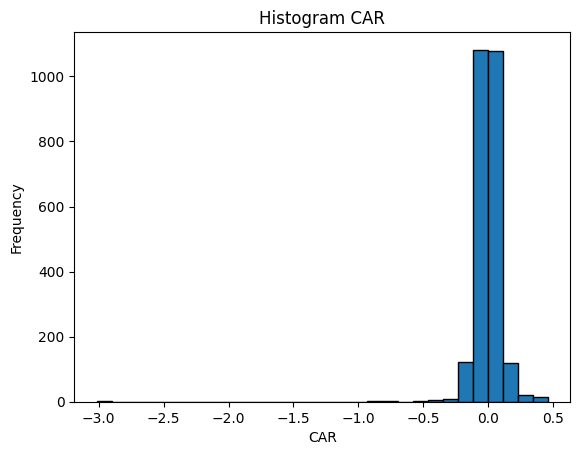

In [ ]:
# Histogram
plt.hist(check["CAR"], bins=30, edgecolor='black')
plt.title("Histogram CAR")
plt.xlabel("CAR")
plt.ylabel("Frequency")
plt.show()

As shown in the graph above, the distribution is highly skewed since it contains **several outliers**. For this reason, we decided to remove them by applying the interquartile range (IQR) rule, **excluding all observations lying below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.**

In [ ]:
# Interquartile range
Q1 = check["CAR"].quantile(0.25)
Q3 = check["CAR"].quantile(0.75)
IQR = Q3 - Q1

# Outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:.3f}, Upper bound: {upper_bound:.3f}")

check_no_out = check[(check["CAR"] >= lower_bound) & (check["CAR"] <= upper_bound)].copy()

removed = len(check) - len(check_no_out)
print(f"Outlier rimossi: {removed} ({removed/len(check)*100:.2f}%)")

Lower bound: -0.166, Upper bound: 0.159
Outlier rimossi: 124 (5.06%)


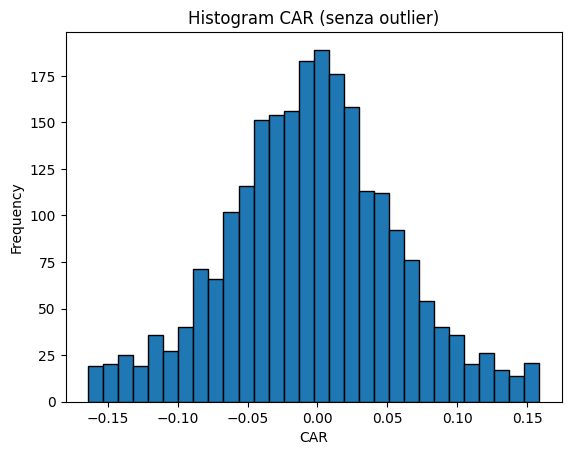

In [ ]:
# New histogram
plt.hist(check_no_out["CAR"], bins=30, edgecolor='black')
plt.title("Histogram CAR (senza outlier)")
plt.xlabel("CAR")
plt.ylabel("Frequency")
plt.show()

The distribution now more closely resembles a normal one, allowing us to proceed with the t-tests.

## T-tests

In [ ]:
def t_test(N, P, alternative="less"):
    """Welch's t-test"""
    N = np.asarray(N, dtype=float)
    P = np.asarray(P, dtype=float)
    N = N[~np.isnan(N)]
    P = P[~np.isnan(P)]

    n_N, n_P = len(N), len(P)

    # SciPy >=1.10 performs directly the one-sided test
    t_stat, p_val = stats.ttest_ind(N, P, equal_var=False, alternative=alternative)
    mean_diff = N.mean() - P.mean()

    print(f"Negative Camp. = {n_N}, Positive Camp. = {n_P}")
    print(f"Mean Neg = {N.mean():.4f}, Mean Pos = {P.mean():.4f}")
    print(f"Δ mean = {mean_diff:.4f}")
    print(f"t = {t_stat:.3f}, p = {p_val:.4g}")

By focusing only on negative campaigns (i.e., those with sentiment equal to −2 or −1), we start by testing the following hypothesis:
$$
H_0 : \mu_N \ge 0
$$
$$
H_1 : \mu_N < 0
$$

where:
- $ \mu_N $ is the mean of the CARs when campaigns are negative

Under the null hypothesis ($H_0$), negative campaigns have no impact on market performance. In contrast, the alternative hypothesis ($H_1$) suggest that CARs are lower when a negative campaign happen, indicating a significant and adverse effect on market reaction.

In [ ]:
# One-sample t-test: H0 = mean(CAR_neg) = 0, H1 = mean(CAR_neg) < 0
sent = check["sentiment"]

check["sent_group"] = pd.Series(pd.NA, index=check.index, dtype="string")
check.loc[sent < 0, "sent_group"] = "neg"
check.loc[sent > 0, "sent_group"] = "pos"

check["sent_group"] = check["sent_group"].astype("category")

car_neg = check.loc[check["sent_group"] == "neg", "CAR"].to_numpy()

t_stat, p_val = stats.ttest_1samp(car_neg, popmean=0, alternative='less')

print("T-test CAR neg:")
print(f"n = {len(car_neg)}")
print(f"Mean = {car_neg.mean():.4f}")
print(f"t = {t_stat:.3f}, p = {p_val:.4g}")

T-test CAR neg:
n = 2063
Mean = -0.0050
t = -1.993, p = 0.02317


Since there seem to be a relationship between sentiment of the campaign and CARs we now test the following hypothesis:
$$
H_0 : \mu_N \ge \mu_P
$$
$$
H_1 : \mu_N < \mu_P
$$

where:  
- $ \mu_N $ = mean of the CARs when campaigns are negative
- $ \mu_P $ = mean of CARs when campaigns are positive

More in detail, in this case under the null hypothesis ($H_0$), negative campaigns have equal or higher CARs than positive ones while the alternative one ($H_1$) states that **CARs are lower for negative campaigns**, implying that such campaigns exert a significant and **detrimental influence on banks' returns**.

In [ ]:
# Check significant differences by Sentiment (-2, -1 vs 1, 2)
car_pos = check.loc[check["sent_group"] == "pos", "CAR"].to_numpy()

print("T-test CAR per sentiment (neg vs pos):")
t_test(car_neg, car_pos)

T-test CAR per sentiment (neg vs pos):
Negative Camp. = 2063, Positive Camp. = 262
Mean Neg = -0.0050, Mean Pos = -0.0045
Δ mean = -0.0004
t = -0.087, p = 0.4652


As shown above, although the mean CAR is slightly lower for negative campaigns (−0.0050 vs −0.0045), **the difference is not statistically significant** (p-value = 0.4652), providing no clear evidence that campaign sentiment influences CARs.

It is worth noting the **imbalance in number of observations**, with negative campaigns being far more frequent (2063 vs. 262), which may further bias the comparison.

The fact that both means are negative suggests that the main drivers of CARs during this period were likely broader macroeconomic factors or other campaign related variables. For this reason we proceed with other statistical tests below.

Adopting a more event-driven approach, we thought that an important occurrence, such as **the Paris agreement** (signed on April 22, 2016) **might have marked a shift in investor behavior** and market perception of banks, reflecting **growing awareness towards climate issues**.

In [ ]:
check["cop21"] = (check["date"] >= pd.Timestamp("2016-04-22")).astype(int)

before= check.loc[check["cop21"] == 0, "CAR"]
after = check.loc[check["cop21"] == 1, "CAR"]
print("T-test CAR per prominence (high vs low):")
t_test(before, after)

T-test CAR per prominence (high vs low):
Negative Camp. = 1509, Positive Camp. = 944
Mean Neg = -0.0037, Mean Pos = -0.0042
Δ mean = 0.0005
t = 0.123, p = 0.5488


However, as shown above, we did not find any statistically significant difference in the CARs between or after COP21 (p-value = 0.5488).

For this reason, we shifted our **focus to Prominence**, assuming that the visibility of a company's mention within a campaign might have influenced investor reactions and, consequently, market outcomes.

In [ ]:
# Check significant differences by Prominence (3, 4 vs 1, 2)
prom = check["prominence"]

check["prom_group"] = pd.Series(pd.NA, index=check.index, dtype="string")
check.loc[prom.isin([3, 4]), "prom_group"] = "high"
check.loc[prom.isin([1, 2]), "prom_group"] = "low"

check["prom_group"] = check["prom_group"].astype("category")

car_high = check.loc[check["prom_group"] == "high", "CAR"].to_numpy()
car_low  = check.loc[check["prom_group"] == "low",  "CAR"].to_numpy()

print("T-test CAR per prominence (high vs low):")
t_test(car_high, car_low)

T-test CAR per prominence (high vs low):
Negative Camp. = 996, Positive Camp. = 1457
Mean Neg = -0.0044, Mean Pos = -0.0036
Δ mean = -0.0008
t = -0.191, p = 0.4244


The mean difference of −0.0008 indicates that campaigns with higher prominence, meaning those in which the company is mentioned more prominently, have, on average, CARs about 0.8 percentage points lower than less prominent ones. This could indicate that, **regardless of the campaign’s tone, being pointed our out by certain organizations tends to be unprofitable for most banks**. However, the p-value (0.4244) shows that this difference is not statistically significant.

However, to **account for the heterogeneity in campaign styles** (that led to  differences in the way banks were mentioned) we **compared campaigns with high and low prominence**. Our goal here is to adopt a broader perspective on how these factors interact to ultimatly graps how they may influence market reactions.

In [ ]:
# Average NGO power
ngo_cols = ["ngo_power1", "ngo_power2", "ngo_power3", "ngo_power4", "ngo_power5"]
check["ngo_power_mean"] = check[ngo_cols].mean(axis=1)

# Subsample: high vs low prominence
x = check.loc[check["prom_group"] == "high", "ngo_power_mean"]
y = check.loc[check["prom_group"] == "low",  "ngo_power_mean"]

t_test(x, y, alternative="greater")

Negative Camp. = 996, Positive Camp. = 1457
Mean Neg = 1.5991, Mean Pos = 1.6117
Δ mean = -0.0126
t = -0.500, p = 0.6915


The p-value (p = 0.6915) indicates that this difference is not statistically significant. Therefore, we find **no evidence that the relative power of NGOs influences how explicitly they mention banks** in their communications (used here as a proxy for their communication style).

In [ ]:
cont_table_1 = pd.crosstab(check["prom_group"], check["sent_group"])
chi2, p, dof, expected = chi2_contingency(cont_table_1)

print(f"Chi² = {chi2:.3f}, p = {p:.4f}")
cont_table_1.round(1)

Chi² = 20.817, p = 0.0000


sent_group,neg,pos
prom_group,,
high,883,73
low,1180,189


In [ ]:
cont_table_1_pct = cont_table_1.div(cont_table_1.sum(axis=1), axis=0) * 100
print("Prominence vs Sentiment (% for row)")
cont_table_1_pct.round(1)

Prominence vs Sentiment (% for row)


sent_group,neg,pos
prom_group,,
high,92.4,7.6
low,86.2,13.8


The Chi² test (χ² = 20.82, p < 0.001) indicates a significant association between campaign prominence and sentiment. More in detail, campaigns with high prominence are predominantly negative (92.4%), while low-prominence campaigns show a slightly higher share of positive sentiment (13.8% vs. 7.6%). This suggests that **when banks are mentioned more prominently, the tone of activist communication tends to be more negative**.

In [ ]:
cont_table_2 = pd.crosstab(check["prom_group"], check["region"])
chi2, p, dof, exp = chi2_contingency(cont_table_2)

print(f"Chi² = {chi2:.2f}, p = {p:.3f}")
cont_table_2

Chi² = 12.27, p = 0.000


region,EU,US
prom_group,,
high,792,204
low,1239,218


In [ ]:
cont_table_2_pct = cont_table_2.div(cont_table_2.sum(axis=1), axis=0) * 100
print("Prominence vs Region (% for row)")
cont_table_2_pct.round(1)

Prominence vs Region (% for row)


region,EU,US
prom_group,,
high,79.5,20.5
low,85.0,15.0


Here, the Chi² test (χ² = 12.27, p < 0.001) reveals a significant association between campaign prominence and region. Campaigns with high prominence are relatively more frequent in the US (20.5%) compared to Europe (79.5%), while low-prominence campaigns are more concentrated in Europe (85.0% vs. 15.0%). We can conclude that **activist campaigns in the US tend to make banks more visibile than those in Europe**.

Since the **campaign-specific variables analyzed so far appear to be strongly interconnected**, isolating the individual effect of each on CARs is not straightforward. To better assess the unique contribution of each factor, we therefore developed a **linear regression model**, allowing us to **control for overlapping influences** and examine the marginal impact of each campaign characteristic on abnormal returns.

## Regressions

In [ ]:
cols = ["CAR", "prominence", "sentiment", "ngo_power_mean", "region", "date", "issue_name1", "issue_name2", "issue_name3"]
check = check[cols].dropna().copy()
check["region"] = check["region"].astype("category")

In [ ]:
formula = "CAR ~  ngo_power_mean + C(region)+ C(prominence) + C(sentiment, Treatment(reference=0)) "

model = smf.ols(formula, data=check).fit(cov_type="HC1")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAR   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     1.563
Date:                Fri, 24 Oct 2025   Prob (F-statistic):              0.121
Time:                        16:25:41   Log-Likelihood:                 1622.5
No. Observations:                2084   AIC:                            -3225.
Df Residuals:                    2074   BIC:                            -3169.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

As shown above **Sentiment seems to be the most relevant variable**. As benchmark we used the neutral campaigns (meaning those with Sentiment = 0). Compared to these, the coefficients for negative sentiment are both negative (in line with our expectations and what we tested above), and the one for **the most negative tone (−2) is statistically significant** (p = 0.007). This means that when activist campaigns are very critical or hostile, banks tend to experience lower CARs.

Earlier, when we tested the average CARs by sentiment group, the results were not significant. This likely happened because all negative campaigns were grouped together, mixing mildly negative and strongly negative cases. Furthermore, in this regression, **by controlling for other factors** (like prominence, region, and NGO power), **we can isolate the specific effect of each sentiment level**, revealing the true impact of strongly negative campaigns.

However, given the low explanatory power (R² = 0.004) of the model, we decided to expand the analysis by **addind the specific topic of each campaign**. We did so since we believed reasonable that certain issues might resonate more strongly with the public and therefore generate a larger market reaction.

In [ ]:
# We included also issue_name3 even if in most cases it is empty
check["issues_concat"] = (check["issue_name1"].fillna("") + " " + check["issue_name2"].fillna("")+ " " + check["issue_name3"].fillna("")).str.lower().str.strip()

# TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words="english", max_features=200)
X_tfidf = vectorizer.fit_transform(check["issues_concat"])

# We chose 6 clusters
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=1, n_init=10)
check["issue_cluster"] = kmeans.fit_predict(X_tfidf)

# Lables
terms = vectorizer.get_feature_names_out()
for i in range(n_clusters):
    cluster_terms = X_tfidf[kmeans.labels_ == i].toarray().sum(axis=0)
    top_terms = [terms[j] for j in cluster_terms.argsort()[-5:][::-1]]
    print(f"Cluster {i}: {', '.join(top_terms)}")


check["issue_cluster"] = check["issue_cluster"].astype("category")

Cluster 0: gas, oil, change, climate, divestment
Cluster 1: tax, transparency, avoidance, havens, financial
Cluster 2: csr, standards, esg, institutions, financial
Cluster 3: mining, coal, impact, environment, divestment
Cluster 4: funding, institutions, financial, industry, arms
Cluster 5: consumer, protection, customer, service, institutions


We manually identified six main clusters. The topics were then generated using **TF-IDF vectorization**, which we selected because LDA and BERT-based topic modeling produced noisier and less interpretable results. Among these, we focused on the three most clearly linked to climate-related issues (Climate Change, ESG, and Coal Impact) whose evolution over time is shown in the graph below.


/tmp/ipython-input-2720720285.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(freq="M"), "issue_cluster"])
/tmp/ipython-input-2720720285.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([pd.Grouper(freq="M"), "issue_cluster"])


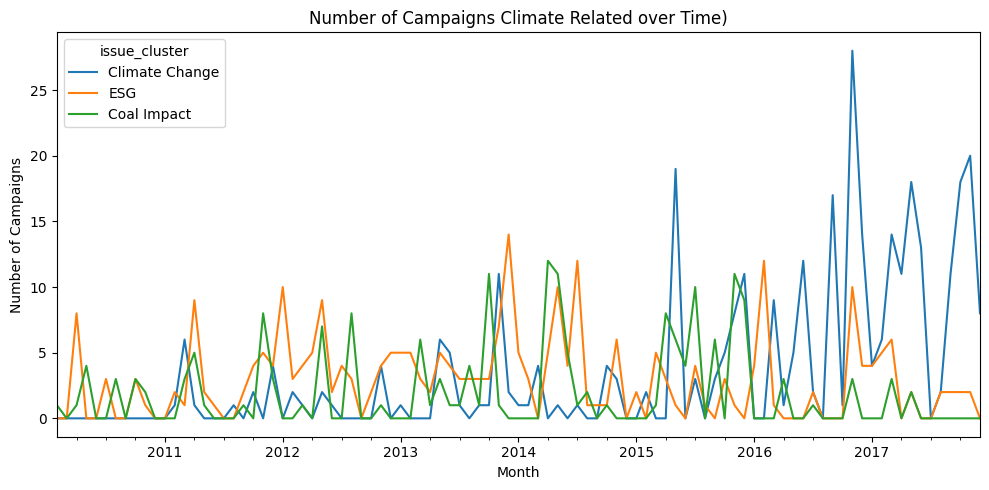

In [ ]:
date_col = "date"

# Group by month and count occurences
monthly = (
    check
    .set_index(date_col)
    .groupby([pd.Grouper(freq="M"), "issue_cluster"])
    .size()
    .unstack(fill_value=0))

# Only campaigns climate related
monthly_filtered = monthly[[0, 2, 3]]

monthly_filtered = monthly_filtered.rename(columns={
    0: "Climate Change",
    2: "ESG",
    3: "Coal Impact"})

# Line plot
ax = monthly_filtered.plot(figsize=(10,5), linewidth=1.5)
ax.set_title("Number of Campaigns Climate Related over Time)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Campaigns")
plt.tight_layout()
plt.show()

The figure highlights a **clear increase in climate-related activism starting from 2015 onward**, with a noticeable spike in Climate Change campaigns after 2016. This trend reflects growing public and institutional attention to environmental concerns following major international events such as the Paris Agreement mentioned before. In contrast, ESG and Coal Impact campaigns show more irregular patterns and remain less frequent overall, suggesting that **the focus of activism has not been uniformly distributed across all climate-related themes**.

In [ ]:
formula = "CAR ~  ngo_power_mean + C(region)+ C(prominence) + C(sentiment, Treatment(reference=0)) + C(issue_cluster)"

model = smf.ols(formula, data=check).fit(cov_type="HC1")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAR   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.921
Date:                Fri, 24 Oct 2025   Prob (F-statistic):             0.0205
Time:                        16:25:41   Log-Likelihood:                 1627.8
No. Observations:                2084   AIC:                            -3226.
Df Residuals:                    2069   BIC:                            -3141.
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

Here we conducted the same regression as before but **we also included all topic clusters** as additional variables to account for the heterogeneity across campaigns since different themes may attract varying levels of public and market attention.

The results show that the inclusion of topics **slightly increases the model’s explanatory power (R² = 0.009)**, but the overall explanatory capacity remains limited. Once again, neither region nor prominence appears to significantly affect CARs, confirming that geographic scope and campaign visibility do not play a major role in explaining market reactions.
Consistent with previous findings, **sentiment remains the main driver of abnormal returns**. In particular, strongly negative campaigns (−2) continue to have a significant and negative effect on CARs (p = 0.006), while mildly negative (−1) and mildly positive (1) tones are only marginally significant. This reinforces the idea that **the intensity of negativity in activist communication is what matters most to investors**.
Among the topic variables, only one cluster (issue_cluster[4]) shows a weakly significant negative effect (p = 0.036), suggesting that some campaign themes may be more sensitive to market perception than others (linked to funding the weapons). However, this effect is modest.

Overall, these results suggest that even after accounting for topic-related heterogeneity, campaign tone remains the main factor influencing market reactions. However, the relatively low explanatory power indicates that the most substantial drivers of CARs are likely linked to broader macroeconomic dynamics.

# **Task 7**: Role of political preferences

In this section, we examine whether **public European climate preferences correlate with firms’ stock reactions to NGO climate campaigns**.

To begin, we restrict the Sigwatch dataset to include **only climate-related issues**, following the keyword-based filtering method described in the example_name_cleaning.txt reference.
Next, we focus on European firms to align the geographic scope with our political-preference data.
Finally, since the available measures of public climate preferences are drawn from European Parliament (EP) election results for 2024, we limit our sample to campaigns occurring after 2017, ensuring temporal consistency between event and preference data.

In [ ]:
ngo_climate = events_with_car.copy()

In [ ]:
ngo_climate = events_with_car.copy()
# our data on climate opinion at country level refers to the current year, therefore we filter our events accordingly
ngo_climate = ngo_climate [ngo_climate["date"] >= pd.Timestamp("2017-01-01")]
# our data on climate opinion at country level is only for European countries
ngo_climate = ngo_climate [ngo_climate["region"] == "EU"]

In [ ]:
issue_cols = ["issue_name1", "issue_name2", "issue_name3"]

climate_keywords = r"""carbon|climate change|coal|mining|oilsands|old[- ]growth logging|
oil(?:\s*&\s*gas| and gas)?|fossil fuels?|pipelines?|logging|gas|drilling(?: offshore)?|
refineries|shale(?: oil)?|fracking|carbon emissions|arctic|ghg emissions|lng|
renewable energy|plastics|methan emissions|shale"""
ngo_climate["climate_issues"] = any_contains(ngo_climate, issue_cols, climate_keywords).astype(int)

# 2) Environmental issues dummy
env_keywords = r"""emissions?|bio ?fuels?|carbon trading|chemicals?|air pollution|
environment|sustainable|palm oil|hydro power|green(?:washing| marketing)?|
land[- ]grabbing|farm(?:ing)?|animal(?: welfare| research)?|enviromental|mining|
pipelines?|oilsands|oilshale|rainforest|paper consumption|forests?|water|pollution|
marine enviroment|agricultural|extraction|biotech|coral reef|earth|dams|power|
conservation|marine wildlife|submarine|deepwater|illegal fishing|waste|biodiversity"""
ngo_climate["environmental_issues"] = any_contains(ngo_climate, issue_cols, env_keywords).astype(int)


# Final climate issues dummy
ngo_climate["climate_issues"] = (
    (ngo_climate["climate_issues"] == 1) |
    (ngo_climate["environmental_issues"] == 1)
).astype(int)
ngo_climate.drop(columns=["environmental_issues"], inplace=True)

ngo_climate=ngo_climate[ngo_climate["climate_issues"]==1]

## Green voting data

The data is scraped at the following [link](https://www.europarl.europa.eu/meps/en/search/table). It shows the **MEPs by Member State and political group**. The MEPs belonging to the **Greens/EFA** group for each country are takes as proxy for green voting data

In [ ]:
df_green = pd.read_excel('./data/Green_party_EU.xlsx')

df_green["Greens/EFA"] = df_green["Greens/EFA"].fillna(0)
df_green.head()
df_green["percent_green_votes"] = df_green["Greens/EFA"] / df_green["Total"]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


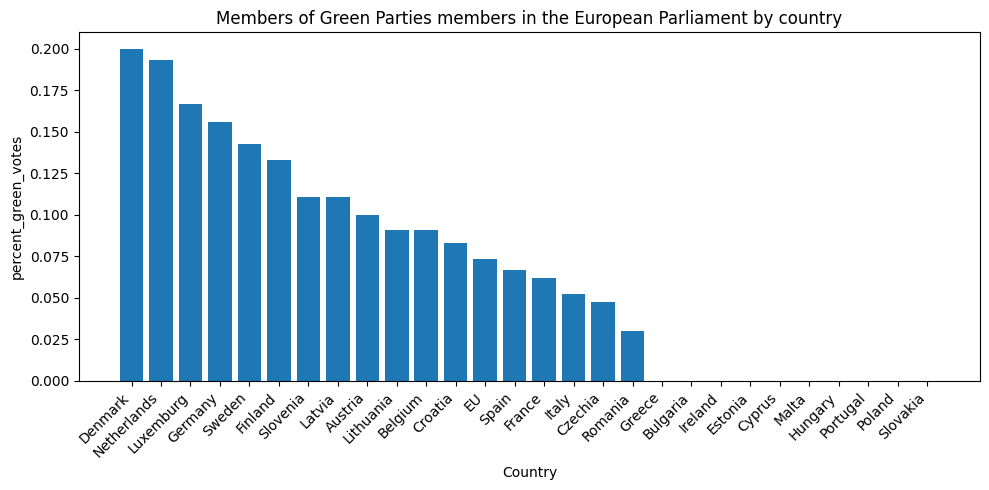

In [ ]:
clim_plot2 = df_green.sort_values("percent_green_votes", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(clim_plot2["Country"], clim_plot2["percent_green_votes"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("percent_green_votes")
plt.xlabel("Country")
plt.title("Members of Green Parties members in the European Parliament by country")
plt.tight_layout()
plt.show()


This bar chart shows the share of **Green/EFA seats in the European Parliament for each EU member state**, used as a proxy for the salience of climate issues in public opinion.

Countries such as Denmark, the Netherlands, Luxembourg, and Germany display the highest green representation, indicating stronger public support for pro-climate policies. In contrast, Eastern and Southern European countries—including Poland, Portugal, Hungary, and Slovakia—show lower shares, reflecting a weaker emphasis on environmental concerns in the political landscape.


---

Here we filter only for European countries present in the ngo data

In [ ]:
countries= set(df_green["Country"]).intersection(set(ngo_climate["company_parent_country"]))
df_green=df_green[df_green["Country"].isin(countries)]

To ease interpretation, we bucket country green shares into two groups: Low, High based on within-sample quantiles.


In [ ]:
labels = ["Low", "High"]

df_green["green_tier_q"] = pd.qcut(
    df_green["percent_green_votes"].rank(method="first"),
    q=2, labels=labels
)

df_green["green_tier_q"] = pd.Categorical(df_green["green_tier_q"], categories=labels, ordered=True)

df_green.head()


,Country,Greens/EFA,Total,percent_green_votes,green_tier_q
0,Belgium,2.0,22,0.090909,Low
4,Germany,15.0,96,0.156250,High
8,Spain,4.0,60,0.066667,Low
9,France,5.0,81,0.061728,Low
11,Italy,4.0,76,0.052632,Low


In [ ]:
merged_climate2 = ngo_climate.merge(
    df_green[["Country", "percent_green_votes", "green_tier_q"]],
    left_on="company_parent_country",
    right_on="Country",
    how="left"
)

merged_climate2.head(3)

,date,company,company_parent_country,sentiment,prominence,report,issue_name1,issue_name2,issue_name3,ngo_name1,...,ngo_power4,ngo_name5,ngo_power5,ret,region,CAR,climate_issues,Country,percent_green_votes,green_tier_q
0,2017-01-18,barclays,UK,-1,2,which accused UK banks of largely failing to ...,Fossil fuels & climate change,"Financial institutions & carbon, divestment",,Christian Aid UK,...,NaN,,NaN,-0.017271,EU,-0.072519,1,NaN,NaN,NaN
1,2017-01-18,hsbc holdings,UK,-1,2,which accused UK banks of largely failing to ...,Fossil fuels & climate change,"Financial institutions & carbon, divestment",,Christian Aid UK,...,NaN,,NaN,-0.020521,EU,0.087221,1,NaN,NaN,NaN
2,2017-01-18,lloyds banking group,UK,-1,2,which accused UK banks of largely failing to ...,Fossil fuels & climate change,"Financial institutions & carbon, divestment",,Christian Aid UK,...,NaN,,NaN,-0.003949,EU,-0.023039,1,NaN,NaN,NaN


For a cleaner signal of negative campaigning, we restrict to **negative sentiment** (−1 and −2).
This concentrates on events more likely to depress valuations if the public is climate-oriented.

In [ ]:
# keep only those with sentiment -1 e -2
merged_climate2 = merged_climate2[merged_climate2["sentiment"].isin([-1, -2])]

In [ ]:
cols = ["CAR", "prominence", "sentiment", "region", "climate_issues", 'green_tier_q', 'percent_green_votes']
merged_climate2 = merged_climate2[cols].dropna().copy()

In [ ]:
formula = "CAR ~  C(green_tier_q)"

model = smf.ols(formula, data=merged_climate2).fit(cov_type="HC1")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAR   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6924
Date:                Fri, 24 Oct 2025   Prob (F-statistic):              0.406
Time:                        16:29:25   Log-Likelihood:                 331.56
No. Observations:                 243   AIC:                            -659.1
Df Residuals:                     241   BIC:                            -652.1
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

This table reports **OLS estimates of the relationship between firms’ cumulative abnormal returns (CAR) and the level of green political support** in the firm’s home country.

The results indicate **no statistically significant relationship** between green political preferences and the CARs following negative NGO climate campaigns. The High-tier coefficient is small and not significantly different from the reference group (Low-tier countries).

Overall, these results suggest that, within this sample, firms headquartered in countries with stronger pro-climate political preferences do not exhibit systematically different market reactions to climate-related NGO events.

To better test this hypothesis, we try, in the following section, with a different dataset.

## New Data


Here, we complement the analysis based on European Parliament voting data with an alternative measure of public climate attitudes.
Specifically, we draw on survey data from the [European Investment Bank (EIB) Climate Survey](https://www.eib.org/en/surveys/climate-survey/2nd-climate-survey/climate-change-impact#:~:text=Overall%2C%2082%25%20of%20Europeans%20report,76%25%20in%20the%20United%20States.), which captures **individual citizens’ perceptions and concerns about climate change** across EU countries.
Unlike the parliamentary data, which reflect political representation in 2024, the EIB survey spans the years between 2019 and 2020, providing a more temporally aligned perspective with our Sigwatch campaign events.


In [ ]:
FILE = "./data/climate-survey-citizens-perception-climate-change-impact-all-data-en.xlsx"

df0 = pd.read_excel(FILE)
df0.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,European mean (vs. Countries),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Q1 In your opinion, what are the three biggest...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,Total Europe,Germany,France,Spain,Italy,UK,The Netherlands,...,Romania,Slovakia,Estonia,Latvia,Lithuania,Slovenia,Cyprus,Malta,Croatia,Luxembourg
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Unweighted basis,NaN,28088,2000,2000,2000,2000,1000,1000,...,1000,500,500,500,501,500,436,150,500,500
7,NaN,NaN,NaN,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
8,NaN,"S/T ""Economic and financial""",NaN,0.670135,0.454084,0.807058,0.885161,0.893358,0.514891,0.554036,...,0.745936,0.691513,0.727492,0.745594,0.774745,0.654311,0.712159,0.448278,0.862914,0.632192
9,NaN,Climate change,NaN,0.466998,0.585937,0.528919,0.418404,0.408413,0.436192,0.560643,...,0.247471,0.297797,0.295642,0.165145,0.275404,0.422173,0.296227,0.70351,0.211624,0.562675


To simplify our analysis, we focus on a single, broad, and representative question from the survey:**“In your opinion, what are the three biggest challenges that citizens in your country are currently facing?”**
We specifically consider the share of respondents who selected **“climate change”** as one of their top three challenges, using this measure as a **proxy for the salience of climate concerns among the public**.

In [ ]:
countries = df0.iloc[4, 4:].tolist()
feeling = df0.iloc[9, 4:].tolist()

In [ ]:
climate= pd.DataFrame({
    "country": countries,
    "Climate_Importance_Opinion": feeling})

climate

,country,Climate_Importance_Opinion
0,Germany,0.585937
1,France,0.528919
2,Spain,0.418404
3,Italy,0.408413
4,UK,0.436192
5,The Netherlands,0.560643
6,Denmark,0.597538
7,Sweden,0.477247
8,Finland,0.464704
9,Belgium,0.471565


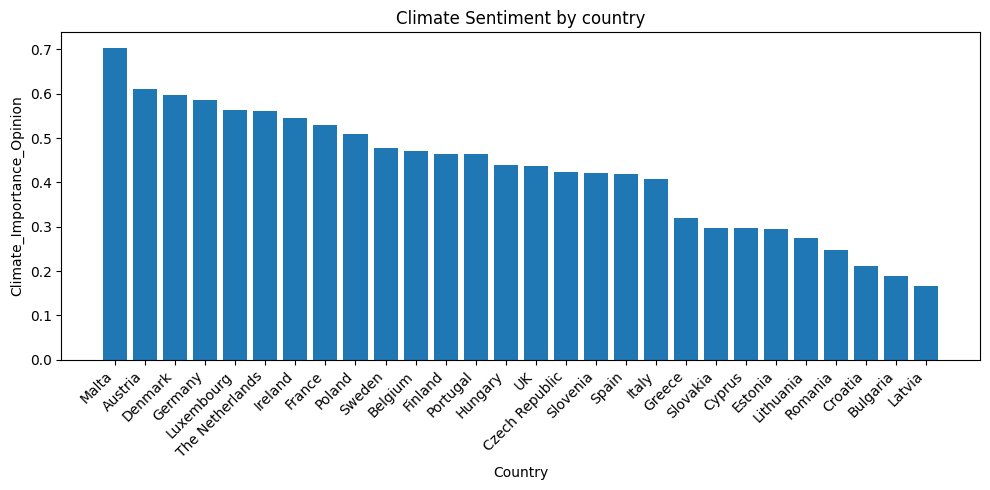

In [ ]:
clim_plot = climate.sort_values("Climate_Importance_Opinion", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(clim_plot["country"], clim_plot["Climate_Importance_Opinion"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Climate_Importance_Opinion")
plt.xlabel("Country")
plt.title("Climate Sentiment by country")
plt.tight_layout()
plt.show()


Here we filter only for European countries present in the ngo data

In [ ]:
countries= set(climate["country"]).intersection(set(ngo_climate["company_parent_country"]))
climate=climate[climate["country"].isin(countries)]

In [ ]:
climate["climate_opinion_z"] = (climate["Climate_Importance_Opinion"] - climate["Climate_Importance_Opinion"].mean()) / climate["Climate_Importance_Opinion"].std()
climate["climate_tier"] = pd.qcut(climate["climate_opinion_z"], 2, labels=["Low","High"])
climate.head()

/tmp/ipython-input-3559733656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  climate["climate_opinion_z"] = (climate["Climate_Importance_Opinion"] - climate["Climate_Importance_Opinion"].mean()) / climate["Climate_Importance_Opinion"].std()
/tmp/ipython-input-3559733656.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  climate["climate_tier"] = pd.qcut(climate["climate_opinion_z"], 2, labels=["Low","High"])


,country,Climate_Importance_Opinion,climate_opinion_z,climate_tier
0,Germany,0.585937,1.233082,High
1,France,0.528919,0.483119,High
2,Spain,0.418404,-0.970505,Low
3,Italy,0.408413,-1.101914,Low
4,UK,0.436192,-0.736533,Low


In [ ]:
# mapping The Netherlands as Netherlands in the climate df
climate.loc[:, "country"] = climate["country"].replace("The Netherlands", "Netherlands")

In [ ]:
merged_climate = ngo_climate.merge(
    climate[["country", "climate_tier"]],
    left_on="company_parent_country",
    right_on="country",
    how="left")

merged_climate.head()

,date,company,company_parent_country,sentiment,prominence,report,issue_name1,issue_name2,issue_name3,ngo_name1,...,ngo_name4,ngo_power4,ngo_name5,ngo_power5,ret,region,CAR,climate_issues,country,climate_tier
0,2017-01-18,barclays,UK,-1,2,which accused UK banks of largely failing to ...,Fossil fuels & climate change,"Financial institutions & carbon, divestment",,Christian Aid UK,...,,NaN,,NaN,-0.017271,EU,-0.072519,1,UK,Low
1,2017-01-18,hsbc holdings,UK,-1,2,which accused UK banks of largely failing to ...,Fossil fuels & climate change,"Financial institutions & carbon, divestment",,Christian Aid UK,...,,NaN,,NaN,-0.020521,EU,0.087221,1,UK,Low
2,2017-01-18,lloyds banking group,UK,-1,2,which accused UK banks of largely failing to ...,Fossil fuels & climate change,"Financial institutions & carbon, divestment",,Christian Aid UK,...,,NaN,,NaN,-0.003949,EU,-0.023039,1,UK,Low
3,2017-01-18,royal bank of sctl.gp.,UK,-1,2,which accused UK banks of largely failing to ...,Fossil fuels & climate change,"Financial institutions & carbon, divestment",,Christian Aid UK,...,,NaN,,NaN,-0.005449,EU,-0.036703,1,UK,Low
4,2017-01-20,deutsche bank,Germany,-1,2,to paying officials to help secure lucrative ...,Corruption and bribery,Financial institutions funding power projects,,National Committee to Combat Climate Change (C...,...,,NaN,,NaN,0.021363,EU,0.075353,1,Germany,High


As before, we focus on events with associated **negative sentimet**.

In [ ]:
# keep only those with sentiment -1 e -2
merged_climate = merged_climate[merged_climate["sentiment"].isin([-1, -2])]

In [ ]:
cols = ["CAR", "prominence", "sentiment", "region", 'climate_tier', "climate_issues", 'date', 'company']
merged_climate = merged_climate[cols].dropna().copy()

In [ ]:
formula = "CAR ~ C(climate_tier)"

model = smf.ols(formula, data=merged_climate).fit(cov_type="HC1")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAR   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.858
Date:                Fri, 24 Oct 2025   Prob (F-statistic):             0.0504
Time:                        16:32:22   Log-Likelihood:                 406.62
No. Observations:                 298   AIC:                            -809.2
Df Residuals:                     296   BIC:                            -801.8
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Compared to the previous results, the regression now shows that firms in the **High-tier countries experience significantly more negative CARs** (−0.014, p = 0.05) compared with firms from Low-tier countries.

# Exploratory Machine Learning Analysis

We tried building a **Random Forest regression model** to predict **Cumulative Abnormal Returns (CAR)** using both numeric and categorical features.

The dataset was enriched with:

* **TF-IDF-based issue clusters** (TF-IDF was chosen over LDA and BERT, which produced noisier and less interpretable topics)
* **Climate and Reddit activity data**
* A **COP21 dummy** to capture the post–Paris Agreement period

Given that our previous linear regressions yielded mostly non-significant results and very low R² values, this step was **exploratory**.
We tested a Random Forest model because it can capture nonlinear relationships and higher-order interactions that linear models cannot.
However, given the overall weak explanatory power of our earlier models, this approach should not be viewed as a more “robust” alternative, but rather as an additional exploratory attempt to check whether a more flexible method could uncover subtle patterns otherwise missed by linear methods.

Our goal was not to predict CARs per se (in which case a broader set of **economic and financial variables** would be needed) but rather to **identify which campaign-related factors** are most closely associated with variations in CAR.

In [ ]:
DATA = events_with_car.copy()

DATA["issues_concat"] = (DATA["issue_name1"].fillna("") + " " + DATA["issue_name2"].fillna("")+ " " + DATA["issue_name3"].fillna("")).str.lower().str.strip()
vectorizer = TfidfVectorizer(stop_words="english", max_features=200)
X_tfidf = vectorizer.fit_transform(DATA["issues_concat"])
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=1, n_init=10)
DATA["issue_cluster"] = kmeans.fit_predict(X_tfidf)
terms = vectorizer.get_feature_names_out()
for i in range(n_clusters):
    cluster_terms = X_tfidf[kmeans.labels_ == i].toarray().sum(axis=0)
    top_terms = [terms[j] for j in cluster_terms.argsort()[-5:][::-1]]
    print(f"Cluster {i}: {', '.join(top_terms)}")

DATA["issue_cluster"] = DATA["issue_cluster"].astype("category")

DATA["cop21"] = (DATA["date"] >= pd.Timestamp("2016-04-22")).astype(int)

df_climate = merged_climate[['company','date', 'climate_tier']].copy()
DATA = DATA.merge(df_climate, on=['company','date'], how='left')

df_r= df_reddit[['company','date', 'reddit_count']].copy()
df_r['date'] = pd.to_datetime(df_r['date'], errors='coerce')
DATA['date'] = pd.to_datetime(DATA['date'], errors='coerce')
DATA = DATA.merge(df_r, on=['company','date'], how='left')

target = "CAR"

candidate_numeric = [
    "prominence", "percent_green_votes",
    "reddit_count",
]
candidate_categ = [
    "sentiment", "region",  "green_tier_q",
    "issue_cluster", "company_parent_country", "cop21", "climate_tier"
]

num_cols = [c for c in candidate_numeric if c in DATA.columns]
cat_cols = [c for c in candidate_categ  if c in DATA.columns]

df_ml = DATA.dropna(subset=[target]).copy()
X = df_ml[num_cols + cat_cols]
y = df_ml[target].values

groups = None
for gcol in ["company", "company_parent", "company_parent_country"]:
    if gcol in df_ml.columns:
        groups = df_ml[gcol].astype(str).values
        break

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", min_frequency=0.01))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
], remainder="drop", verbose_feature_names_out=False)

rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("rf", rf)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

if groups is not None:
    cv = GroupKFold(n_splits=5)
    cv_groups = groups[df_ml.index.isin(X_train.index)] if hasattr(X_train, "index") else groups[:len(X_train)]
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

else:
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2").mean()
mae_cv = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error").mean()
rmse_cv= (-cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error").mean())

print(f"CV (train) — R²: {r2_cv:.3f} | MAE: {mae_cv:.5f} | RMSE: {rmse_cv:.5f}")

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("\nHoldout (test)")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.5f}")

def get_feature_names(pipeline, num_cols, cat_cols):
    prep = pipeline.named_steps["preprocess"]
    names = []

    names += list(num_cols)

    if len(cat_cols):
        ohe = prep.named_transformers_["cat"].named_steps["onehot"]
        names += list(ohe.get_feature_names_out(cat_cols))
    return names

all_names = get_feature_names(pipe, num_cols, cat_cols)
fi = pipe.named_steps["rf"].feature_importances_
feat_imp = pd.DataFrame({"feature": all_names, "importance": fi}).sort_values("importance", ascending=False)

def base_name(s):
    return s.split("_", 1)[0] if "_" in s and s.split("_",1)[0] in cat_cols else s.split("__")[0] if "__" in s else s.split(":")[0]
grouped_imp = feat_imp.assign(group=feat_imp["feature"].apply(base_name)).groupby("group")["importance"].sum().sort_values(ascending=False)

print("\nTop features (aggregated):")
display(grouped_imp.head(10))

Cluster 0: tax, transparency, avoidance, havens, financial
Cluster 1: institutions, financial, consumer, protection, customer
Cluster 2: gas, oil, carbon, divestment, change
Cluster 3: industry, arms, funding, regulatory, influence
Cluster 4: csr, standards, esg, institutions, financial
Cluster 5: mining, coal, impact, environment, divestment
CV (train) — R²: 0.022 | MAE: 0.06600 | RMSE: 0.11349

Holdout (test)
R²:   0.033
MAE:  0.06314

Top features (aggregated):


,importance
group,
prominence,0.289748
sentiment,0.135951
issue_cluster_1,0.062087
cop21,0.058400
issue_cluster_0,0.046856
company_parent_country_UK,0.045841
issue_cluster_2,0.040389
issue_cluster_3,0.038208
issue_cluster_5,0.037555


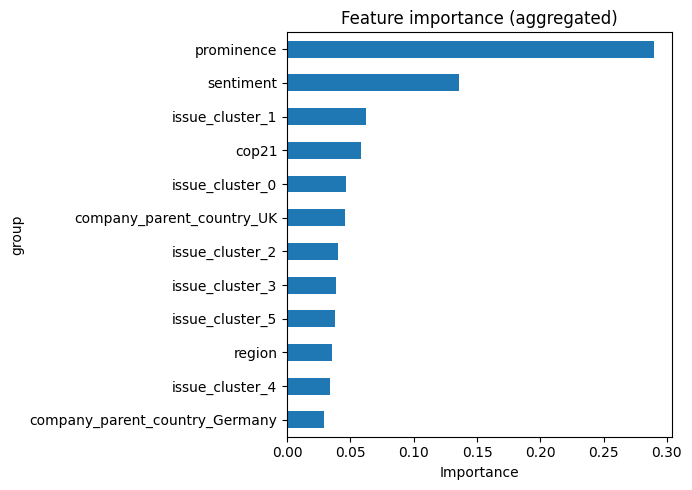

In [ ]:
top = grouped_imp.head(12).iloc[::-1]
plt.figure(figsize=(7,5))
top.plot(kind="barh")
plt.title("Feature importance (aggregated)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

The model's performance, however, remained very limited, as one can see from the $R^2$ values.

While the predictive power was weak, feature importance analysis suggested that prominence and sentiment were the most influential predictors, followed by some issue clusters and the COP21 variable.

Overall, these results reinforce that CAR responses are difficult to explain with the available features, and that even more flexible machine learning methods did not substantially improve explanatory performance.

# Possible Further Improvements

If we had more time, we would try to strengthen our analysis in the following ways:

* **Enhance data collection:** we would improve our scraping strategy by using more sophisticated (often non-free) tools and extend it to include newspaper sources. By combining this richer dataset would be able to conduct a more comprehensive sentiment analysis, helping us better understand public perceptions of NGO campaigns around specific events. The increased data volume would also allow for a more accurate assessment of campaign prominence.

* **Refine the financial model:** we would incorporate the Fama-French five-factor model, if data are available from 2010 onward (currently, we only found reliable data for 2020-2025, which was not compatible with our dataset).

* **Optimize event study parameters:** we experimented with different CAR windows without substantial improvement, and in the end we mostly followed the setup used in Krueger et al. Further fine tuning, such as adjusting the 250-day rolling window, the 50-day estimation period, and the 10-day CAR event window, could lead to more robust results.

* **Explore advanced machine learning approaches**: we experimented with a simple Random Forest model as an initial step, but results were limited. With more time, we would extend this analysis by testing more sophisticated ML techniques, such as tuned Random Forests or Neural Networks. These methods could enable the inclusion of a broader set of nonlinear interactions, potentially improving our understanding of the complex dynamics driving market reactions.